# ModelNet10 chairs as vertices of one GraphPCA graph

This notebook constructs an object-level graph from the chair category of
ModelNet10:

$$
\text{3D chair mesh}
\longrightarrow
\text{surface point cloud}
\longrightarrow
\text{object-to-object distance}
\longrightarrow
\text{one dataset-level graph}
\longrightarrow
\text{GraphPCA coordinates}.
$$

Each graph vertex is an **entire chair mesh**, not a mesh vertex. The official
ModelNet10 train/test split is retained, and the present configuration uses all
available chair meshes from both partitions. Each mesh is represented by 5,000
points sampled independently and uniformly with respect to surface area. A
sliced-Wasserstein approximation supplies object-to-object distances, and a
connected k-nearest-neighbor graph is passed to GraphPCA.

The official ModelNet10 archive is about 450 MB. Sampled point clouds are
cached. Dataset source: [Princeton ModelNet](https://modelnet.cs.princeton.edu/).

This visualization experiment is **transductive**: the object graph contains
both training and test meshes. Their labels are not used to construct the graph
or fit GraphPCA; the split is retained only as object metadata in the
interactive browser.


In [1]:
import importlib
import sys
import time
from pathlib import Path
import hashlib
import subprocess
import sys
import tempfile
import importlib
import importlib.util
import urllib.request
import tempfile
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.spatial.distance import (
    pdist,
    squareform,
)

## 0. The unified GraphPCA core

Every GraphPCA notebook in this project calls the implementation
`graphpca_core_annotated.py`.

In [2]:
# --- locate and import the unified core ----------------------------------
# Put graphpca_core_annotated.py next to this notebook. In Colab: the file pane on the
# left (it survives until the runtime is recycled), or keep it in Drive and
# mount it, which survives restarts.

_candidates = [Path.cwd(), Path("/content"), Path("/content/drive/MyDrive"),
               Path.cwd() / "upload", Path("/content/drive/MyDrive/graphpca")]
_home = next((p for p in _candidates if (p / "graphpca_core_annotated.py").exists()), None)
if _home is None:
    raise FileNotFoundError(
        "graphpca_core_annotated.py not found. Upload it next to this notebook and "
        "rerun this cell. Searched: " + ", ".join(str(p) for p in _candidates))
if str(_home) not in sys.path:
    sys.path.insert(0, str(_home))

import numpy as np
import graphpca_core_annotated
from graphpca_core_annotated import (
    graphpca, check_graphpca, graph_heat_kernel, laplacian_eigh,
    diffusion_distance_potential, edge_flows, rank_capacity,
    align_pc_signs,
    degenerate_blocks, block_magnitude, block_angle, block_summary,
    check_block_invariance,
    plot_eigenvalues, plot_variance_explained, plot_cumulative_variance,
    plot_spectrum_across_t, plot_block_magnitude,
)

print("graphpca_core_annotated loaded from", _home / "graphpca_core_annotated.py")


graphpca_core_annotated loaded from /content/graphpca_core_annotated.py


In [3]:
from graphpca_core_annotated import fit_graphpca


def import_or_install_networkx():
    try:
        return importlib.import_module("networkx")
    except ImportError:
        vendor = CACHE / "vendor"
        vendor.mkdir(exist_ok=True)
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", "--target", str(vendor), "networkx"]
        )
        sys.path.insert(0, str(vendor.resolve()))
        return importlib.import_module("networkx")

nx = import_or_install_networkx()


## Experiment configuration

The chair category and the official train/test split are retained. Setting the
per-partition limits below to `None` includes all available chair meshes. The
number of selected meshes is printed when the data are loaded, so that the
paper can report the realized sample size without relying on a hard-coded
count.

The diffusion parameter is specified only in **real time** $t$ in `T_VALUES`, and GraphPCA is fitted at every $t$ in `T_VALUES`. Moreover, `t=10` is the time parameter selected for display.

In [4]:
CACHE = Path("./graphpca_cache")
CACHE.mkdir(parents=True, exist_ok=True)

In [5]:
DATA_URL = "http://3dvision.princeton.edu/projects/2014/3DShapeNets/ModelNet10.zip"

CLASSES = (
    #"bathtub",
    #"bed",
    "chair",
    #"desk",
    #"dresser",
    #"monitor",
    #"night_stand",
    #"sofa",
    #"table",
    #"toilet",
)

# None means: use every mesh in the corresponding official partition.
N_TRAIN_PER_CLASS = None  # For a smaller experiment, use N_TRAIN_PER_CLASS = 200
N_TEST_PER_CLASS = None   # For a smaller experiment, use N_TEST_PER_CLASS = 50

N_SURFACE_POINTS = 5000
N_SLICES = 64
KNN_START = 10

# Real diffusion times passed directly to fit_graphpca(t_values=...).
T_VALUES = (0.5, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 50, 100)
T_TO_BROWSE = 10
T_TO_PLOT = 10

K_PCS = 5
SEED = 42

ARCHIVE_PATH = CACHE / "ModelNet10.zip"
EXTRACT_ROOT = CACHE / "selected_classes"
DATA_ROOT = EXTRACT_ROOT / "ModelNet10"

In [6]:
if not ARCHIVE_PATH.exists():
    print("Downloading ModelNet10 once (approximately 450 MB)...")
    urllib.request.urlretrieve(DATA_URL, ARCHIVE_PATH)
else:
    print("Using cached archive:", ARCHIVE_PATH)

needed_marker = DATA_ROOT / CLASSES[-1] / "test"
if not needed_marker.exists():
    print("Extracting selected classes...")
    EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
    prefixes = tuple(f"ModelNet10/{category}/" for category in CLASSES)
    with zipfile.ZipFile(ARCHIVE_PATH) as archive:
        members = [
            name for name in archive.namelist()
            if name.endswith(".off") and name.startswith(prefixes)
        ]
        for name in members:
            archive.extract(name, EXTRACT_ROOT)
else:
    print("Using cached extracted classes.")

for category in CLASSES:
    n_train = len(list((DATA_ROOT / category / "train").glob("*.off")))
    n_test = len(list((DATA_ROOT / category / "test").glob("*.off")))
    print(f"{category:>6}: train={n_train}, test={n_test}")


Extracting selected classes...
 chair: train=889, test=100


## Convert every mesh into a normalized surface point cloud


In [7]:
def content_lines(path):
    lines = []
    with Path(path).open("r", encoding="utf-8", errors="ignore") as stream:
        for raw in stream:
            line = raw.split("#", 1)[0].strip()
            if line:
                lines.append(line)
    return lines


def load_off(path):
    lines = content_lines(path)
    if not lines or not lines[0].startswith("OFF"):
        raise ValueError(f"Not an OFF file: {path}")

    if lines[0] == "OFF":
        counts = lines[1].split()
        cursor = 2
    else:
        counts = lines[0][3:].strip().split()
        cursor = 1

    n_vertices, n_faces = int(counts[0]), int(counts[1])
    vertices = np.asarray(
        [[float(value) for value in lines[cursor + i].split()[:3]] for i in range(n_vertices)],
        dtype=float,
    )
    cursor += n_vertices

    triangles = []
    for i in range(n_faces):
        values = [int(value) for value in lines[cursor + i].split()]
        face = values[1 : 1 + values[0]]
        for j in range(1, len(face) - 1):
            triangles.append((face[0], face[j], face[j + 1]))
    return vertices, np.asarray(triangles, dtype=int)


def sample_surface_points(vertices, triangles, n_points, rng):
    tri = vertices[triangles]
    areas = 0.5 * np.linalg.norm(
        np.cross(tri[:, 1] - tri[:, 0], tri[:, 2] - tri[:, 0]),
        axis=1,
    )
    positive = areas > np.finfo(float).eps
    tri, areas = tri[positive], areas[positive]
    if len(areas) == 0:
        raise ValueError("Mesh has zero surface area.")

    chosen = rng.choice(len(tri), size=n_points, replace=True, p=areas / areas.sum())
    picked = tri[chosen]
    u, v = rng.random(n_points), rng.random(n_points)
    reflect = u + v > 1.0
    u[reflect], v[reflect] = 1.0 - u[reflect], 1.0 - v[reflect]
    points = (
        picked[:, 0]
        + u[:, None] * (picked[:, 1] - picked[:, 0])
        + v[:, None] * (picked[:, 2] - picked[:, 0])
    )
    points -= points.mean(axis=0, keepdims=True)
    return points / np.linalg.norm(points, axis=1).max()


def stable_rng(path):
    relative_name = str(path).split("ModelNet10", 1)[-1]
    digest = hashlib.sha256(relative_name.encode("utf-8")).digest()
    path_seed = int.from_bytes(digest[:8], "little")
    return np.random.default_rng((path_seed + SEED) % (2**63 - 1))


def reproducible_subset(files, limit, seed):
    """Choose a reproducible random subset while preserving stable ordering."""
    files = sorted(files)
    if limit is None or limit >= len(files):
        return files
    rng = np.random.default_rng(seed)
    selected = np.sort(rng.choice(len(files), size=limit, replace=False))
    return [files[index] for index in selected]


def selected_files():
    paths, labels, train_mask = [], [], []
    for label, category in enumerate(CLASSES):
        train_all = (DATA_ROOT / category / "train").glob("*.off")
        test_all = (DATA_ROOT / category / "test").glob("*.off")

        train = reproducible_subset(
            train_all,
            N_TRAIN_PER_CLASS,
            seed=SEED + 1000 * label,
        )
        test = reproducible_subset(
            test_all,
            N_TEST_PER_CLASS,
            seed=SEED + 1000 * label + 1,
        )

        paths.extend(train + test)
        labels.extend([label] * (len(train) + len(test)))
        train_mask.extend([True] * len(train) + [False] * len(test))

        print(
            f"Selected {category:>6}: "
            f"train={len(train)}, test={len(test)}"
        )

    return paths, np.asarray(labels), np.asarray(train_mask)


paths, labels, train_mask = selected_files()

clouds = []
for index, path in enumerate(paths, start=1):
    vertices, triangles = load_off(path)
    clouds.append(
        sample_surface_points(vertices, triangles, N_SURFACE_POINTS, stable_rng(path))
    )
    if index % 25 == 0 or index == len(paths):
        print(f"Sampled {index}/{len(paths)} objects")
point_clouds = np.stack(clouds)

print("Objects:", len(paths))
print("Point-cloud tensor:", point_clouds.shape)

Selected  chair: train=889, test=100
Sampled 25/989 objects
Sampled 50/989 objects
Sampled 75/989 objects
Sampled 100/989 objects
Sampled 125/989 objects
Sampled 150/989 objects
Sampled 175/989 objects
Sampled 200/989 objects
Sampled 225/989 objects
Sampled 250/989 objects
Sampled 275/989 objects
Sampled 300/989 objects
Sampled 325/989 objects
Sampled 350/989 objects
Sampled 375/989 objects
Sampled 400/989 objects
Sampled 425/989 objects
Sampled 450/989 objects
Sampled 475/989 objects
Sampled 500/989 objects
Sampled 525/989 objects
Sampled 550/989 objects
Sampled 575/989 objects
Sampled 600/989 objects
Sampled 625/989 objects
Sampled 650/989 objects
Sampled 675/989 objects
Sampled 700/989 objects
Sampled 725/989 objects
Sampled 750/989 objects
Sampled 775/989 objects
Sampled 800/989 objects
Sampled 825/989 objects
Sampled 850/989 objects
Sampled 875/989 objects
Sampled 900/989 objects
Sampled 925/989 objects
Sampled 950/989 objects
Sampled 975/989 objects
Sampled 989/989 objects
Object

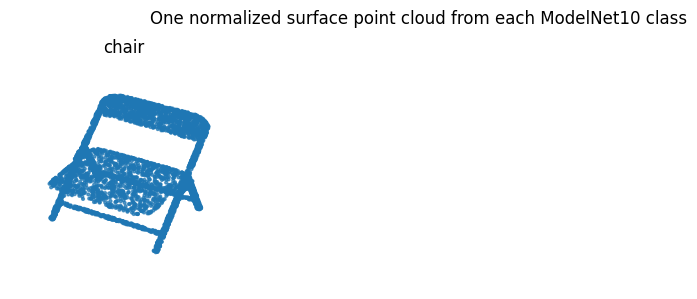

In [8]:
def class_object_indices(class_index, category):
    """Return object indices for integer-coded or category-name labels."""
    label_array = np.asarray(labels)

    if label_array.dtype.kind in {"U", "S"}:
        return np.flatnonzero(label_array.astype(str) == str(category))

    if label_array.dtype.kind == "O":
        name_matches = np.flatnonzero(label_array.astype(str) == str(category))
        if name_matches.size:
            return name_matches

    return np.flatnonzero(label_array == class_index)


N_CLASS_COLUMNS = 3
N_CLASS_ROWS = int(np.ceil(len(CLASSES) / N_CLASS_COLUMNS))

fig = plt.figure(figsize=(3 * N_CLASS_COLUMNS, 3 * N_CLASS_ROWS))
plotted_classes = 0

for class_index, category in enumerate(CLASSES):
    object_indices = class_object_indices(class_index, category)
    if object_indices.size == 0:
        print(
            f"No object found for {category!r}. "
            f"Available labels: {np.unique(labels)!r}"
        )
        continue

    object_index = int(object_indices[0])
    cloud = point_clouds[object_index]
    ax = fig.add_subplot(
        N_CLASS_ROWS,
        N_CLASS_COLUMNS,
        class_index + 1,
        projection="3d",
    )
    ax.scatter(*cloud.T, s=4, alpha=0.7)
    ax.set_title(category.replace("_", " "))
    ax.set_axis_off()
    plotted_classes += 1

if plotted_classes:
    plt.suptitle("One normalized surface point cloud from each ModelNet10 class")
    plt.tight_layout()
    plt.show()
else:
    plt.close(fig)
    raise ValueError(
        "None of CLASSES matched labels. Rerun the point-cloud construction "
        "cell after changing CLASSES."
    )


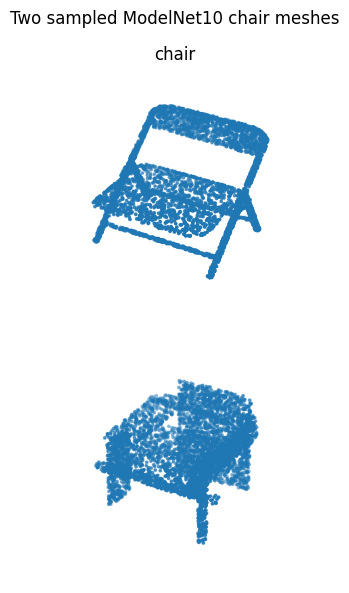

In [9]:
N_SHOW = 2
N_CLASS_COLUMNS = min(5, len(CLASSES))
N_CLASS_BLOCK_ROWS = int(np.ceil(len(CLASSES) / N_CLASS_COLUMNS))
N_PLOT_ROWS = N_CLASS_BLOCK_ROWS * N_SHOW

fig = plt.figure(figsize=(3 * N_CLASS_COLUMNS, 3 * N_PLOT_ROWS))

for class_index, category in enumerate(CLASSES):
    object_indices = np.flatnonzero(labels == class_index)
    class_block_row = class_index // N_CLASS_COLUMNS
    column = class_index % N_CLASS_COLUMNS

    for example_index in range(min(N_SHOW, len(object_indices))):
        row = class_block_row * N_SHOW + example_index
        subplot_index = row * N_CLASS_COLUMNS + column + 1
        cloud = point_clouds[object_indices[example_index]]

        ax = fig.add_subplot(
            N_PLOT_ROWS,
            N_CLASS_COLUMNS,
            subplot_index,
            projection="3d",
        )
        ax.scatter(*cloud.T, s=3)
        if example_index == 0:
            ax.set_title(category.replace("_", " "))
        ax.set_axis_off()

plt.suptitle("Two sampled ModelNet10 chair meshes")
plt.tight_layout()
plt.show()


## Object distances and the dataset-level graph

For random unit directions $\theta_\ell$, each cloud is projected to one dimension and sorted. The Euclidean distance between these sorted projections approximates sliced $W_2$. It is invariant to the ordering of points. ModelNet10 supplies aligned orientations; for an unaligned dataset, an alignment or rotation-invariant distance would be needed.


In [10]:
rng = np.random.default_rng(SEED)
directions = rng.normal(size=(N_SLICES, 3))
directions /= np.linalg.norm(directions, axis=1, keepdims=True)

projected = point_clouds @ directions.T          # (objects, points, slices)
projected.sort(axis=1)
sw_descriptors = np.transpose(projected, (0, 2, 1)).reshape(len(paths), -1)
object_distances = squareform(pdist(sw_descriptors, metric="euclidean"))
object_distances /= np.sqrt(sw_descriptors.shape[1])


def connected_knn_graph(distances, starting_k=8):
    n = len(distances)
    for k in range(starting_k, n):
        graph = nx.Graph()
        graph.add_nodes_from(range(n))
        for i in range(n):
            for j in np.argsort(distances[i])[1 : k + 1]:
                j = int(j)
                length = max(float(distances[i, j]), 1e-12)
                if graph.has_edge(i, j):
                    graph[i][j]["weight"] = min(graph[i][j]["weight"], length)
                else:
                    graph.add_edge(i, j, weight=length)
        if nx.is_connected(graph):
            return graph, k
    raise RuntimeError("Could not construct a connected kNN graph.")


object_graph, used_k = connected_knn_graph(object_distances, KNN_START)
print("Graph vertices (objects):", object_graph.number_of_nodes())
print("Graph edges:", object_graph.number_of_edges())
print("Connected-k value:", used_k)


Graph vertices (objects): 989
Graph edges: 7271
Connected-k value: 10


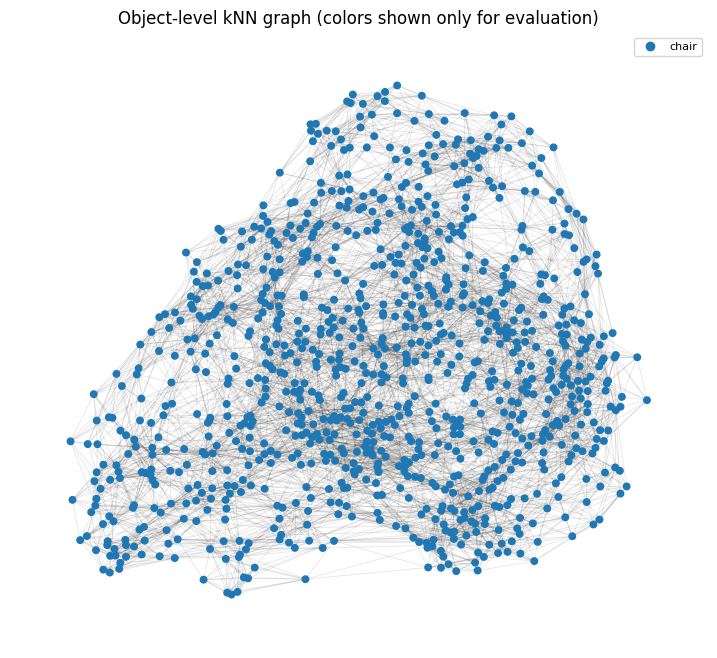

In [11]:
class_cmap = plt.get_cmap("tab10", len(CLASSES))
colors = class_cmap(labels)
positions = nx.spring_layout(object_graph, seed=SEED, weight=None)

plt.figure(figsize=(9, 8))
nx.draw_networkx_edges(object_graph, positions, alpha=0.10, width=0.6)
nx.draw_networkx_nodes(
    object_graph,
    positions,
    node_color=colors,
    node_size=22,
)

legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=class_cmap(index),
        markeredgecolor="none",
        markersize=7,
        label=category.replace("_", " "),
    )
    for index, category in enumerate(CLASSES)
]

plt.legend(
    handles=legend_handles,
    ncol=2,
    fontsize=8,
    loc="best",
)
plt.title("Object-level kNN graph (colors shown only for evaluation)")
plt.axis("off")
plt.show()


## Vertex measures on the object graph


In [12]:
n = len(paths)

edge_lengths = np.array([
    data["weight"]
    for _, _, data in object_graph.edges(data=True)
])
sigma = np.median(edge_lengths)

affinity_degree = np.zeros(n)

for u, v, data in object_graph.edges(data=True):
    length = data["weight"]
    affinity = np.exp(-(length**2) / (2 * sigma**2))

    affinity_degree[u] += affinity
    affinity_degree[v] += affinity

In [13]:
# Uniform
mu_uniform = np.ones(n)
mu_uniform /= mu_uniform.sum()

# Degree weighted: emphasizes common/central shapes
mu_degree = affinity_degree / affinity_degree.sum()

# Inverse-density weighted: emphasizes uncommon shapes
mu_inverse = 1.0 / np.sqrt(affinity_degree + 1e-12)
mu_inverse /= mu_inverse.sum()

## Fit GraphPCA at real diffusion time $t$

We use the uniform probability measure on the object vertices. GraphPCA is
fitted once at the real diffusion times listed in `T_VALUES`. Consequently,
every row of `result.coeffs_dict[t]` is a fixed-dimensional signature for one
complete ModelNet chair mesh.


In [14]:
# Input vertex measure
mu_objects = mu_uniform


def fitted_time_key(fitted_result, requested_t):
    """Return the stored key matching one requested real diffusion time."""

    available = np.asarray(
        fitted_result.t_values,
        dtype=float,
    )
    matches = np.flatnonzero(
        np.isclose(
            available,
            requested_t,
            rtol=1e-12,
            atol=1e-12,
        )
    )

    if matches.size == 0:
        raise ValueError(
            f"t={requested_t:g} was not fitted. "
            f"Available real times are {fitted_result.t_values}."
        )

    return fitted_result.t_values[int(matches[0])]


result = fit_graphpca(
    object_graph,
    potential_function="heat_kernel",
    t_values=T_VALUES,
    mu=mu_objects,
    k_keep=20,
    k_pcs=K_PCS,
    verbose=True,
)

for time_key in result.t_values:
    print(
        f"t={float(time_key):g}: "
        f"object signatures={result.coeffs_dict[time_key].shape}"
    )


t=0.5: 20 components, total variance 2.152591e+00
t=1: 20 components, total variance 3.334234e-01
t=1.5: 20 components, total variance 1.142935e-01
t=2: 20 components, total variance 5.146682e-02
t=3: 20 components, total variance 1.449357e-02
t=4: 20 components, total variance 5.094539e-03
t=5: 20 components, total variance 2.040069e-03
t=6: 20 components, total variance 8.902735e-04
t=7: 20 components, total variance 4.117117e-04
t=8: 20 components, total variance 1.980566e-04
t=9: 20 components, total variance 9.789833e-05
t=10: 20 components, total variance 4.932155e-05
t=15: 13 components, total variance 1.857255e-06
t=20: 9 components, total variance 7.792654e-08
t=25: 7 components, total variance 3.411996e-09
t=30: 6 components, total variance 1.523935e-10
t=35: 5 components, total variance 6.871735e-12
t=50: 4 components, total variance 6.421549e-16


/content/graphpca_core_annotated.py:1257: RuntimeWarning: t=100.0: centring left only round-off (ratio 4.22e-13). Everything returned for this time is noise, not signal. Use a smaller t.
  result = graphpca(D, setup.K, ell=setup.ell, mu=mu, t=t,


t=100: 20 components, total variance 2.447921e-29
t=0.5: object signatures=(989, 5)
t=1: object signatures=(989, 5)
t=1.5: object signatures=(989, 5)
t=2: object signatures=(989, 5)
t=3: object signatures=(989, 5)
t=4: object signatures=(989, 5)
t=5: object signatures=(989, 5)
t=6: object signatures=(989, 5)
t=7: object signatures=(989, 5)
t=8: object signatures=(989, 5)
t=9: object signatures=(989, 5)
t=10: object signatures=(989, 5)
t=15: object signatures=(989, 5)
t=20: object signatures=(989, 5)
t=25: object signatures=(989, 5)
t=30: object signatures=(989, 5)
t=35: object signatures=(989, 5)
t=50: object signatures=(989, 4)
t=100: object signatures=(989, 5)


In [15]:
# Numeric tables are kept in this dictionary for later analysis or export.
# Keys are real diffusion times t.
graphpca_variance_tables = {}

for time_key in result.t_values:
    t = float(time_key)

    # evals_dict is ascending; reverse it to match PC1-first outputs.
    eigenvalues = np.asarray(
        result.evals_dict[time_key],
        dtype=float,
    )[::-1]
    explained = np.asarray(
        result.pc_var_ratio_dict[time_key],
        dtype=float,
    )
    cumulative = np.asarray(
        result.pc_cum_ratio_dict[time_key],
        dtype=float,
    )

    if not (
        len(eigenvalues)
        == len(explained)
        == len(cumulative)
    ):
        raise RuntimeError(
            f"Inconsistent GraphPCA variance arrays at t={t:g}: "
            f"{len(eigenvalues)}, {len(explained)}, {len(cumulative)}"
        )

    table = pd.DataFrame(
        {
            "PC": np.arange(1, len(eigenvalues) + 1),
            "eigenvalue": eigenvalues,
            "explained_variance_ratio": explained,
            "cumulative_explained_variance_ratio": cumulative,
        }
    )
    graphpca_variance_tables[t] = table

    retained_fraction = (
        float(cumulative[-1])
        if len(cumulative)
        else 0.0
    )
    print(
        f"t={t:g} | "
        f"total variance={result.total_var_dict[time_key]:.6e} | "
        f"retained PCs={len(eigenvalues)} | "
        f"retained cumulative variance={retained_fraction:.4%}"
    )

    display_table = table.copy()
    display_table["eigenvalue"] = display_table["eigenvalue"].map(
        lambda value: f"{value:.6e}"
    )
    display_table["explained_variance_ratio"] = (
        display_table["explained_variance_ratio"].map(
            lambda value: f"{value:.4%}"
        )
    )
    display_table["cumulative_explained_variance_ratio"] = (
        display_table["cumulative_explained_variance_ratio"].map(
            lambda value: f"{value:.4%}"
        )
    )
    display(display_table)
    print()


t=0.5 | total variance=2.152591e+00 | retained PCs=20 | retained cumulative variance=27.7245%


,PC,eigenvalue,explained_variance_ratio,cumulative_explained_variance_ratio
0,1,6.417427e-02,2.9813%,2.9813%
1,2,6.177461e-02,2.8698%,5.8510%
2,3,5.384957e-02,2.5016%,8.3527%
3,4,4.125840e-02,1.9167%,10.2693%
4,5,3.869041e-02,1.7974%,12.0667%
5,6,3.573206e-02,1.6600%,13.7267%
6,7,2.671366e-02,1.2410%,14.9677%
7,8,2.571588e-02,1.1946%,16.1623%
8,9,2.415439e-02,1.1221%,17.2844%
9,10,2.325854e-02,1.0805%,18.3649%



t=1 | total variance=3.334234e-01 | retained PCs=20 | retained cumulative variance=68.2516%


,PC,eigenvalue,explained_variance_ratio,cumulative_explained_variance_ratio
0,1,3.190095e-02,9.5677%,9.5677%
1,2,2.784639e-02,8.3517%,17.9194%
2,3,2.544893e-02,7.6326%,25.5520%
3,4,1.294499e-02,3.8824%,29.4344%
4,5,1.221298e-02,3.6629%,33.0973%
5,6,1.113655e-02,3.3401%,36.4374%
6,7,1.025301e-02,3.0751%,39.5125%
7,8,9.637555e-03,2.8905%,42.4029%
8,9,9.316772e-03,2.7943%,45.1972%
9,10,8.983707e-03,2.6944%,47.8916%



t=1.5 | total variance=1.142935e-01 | retained PCs=20 | retained cumulative variance=88.8498%


...

,PC,eigenvalue,explained_variance_ratio,cumulative_explained_variance_ratio
0,1,6.818309e-12,99.2225%,99.2225%
1,2,5.341409e-14,0.7773%,99.9998%
2,3,1.071344e-17,0.0002%,100.0000%
3,4,1.348649e-18,0.0000%,100.0000%
4,5,1.212364e-21,0.0000%,100.0000%



t=50 | total variance=6.421549e-16 | retained PCs=4 | retained cumulative variance=100.0000%


,PC,eigenvalue,explained_variance_ratio,cumulative_explained_variance_ratio
0,1,6.416269e-16,99.9178%,99.9178%
1,2,5.280009e-19,0.0822%,100.0000%
2,3,2.501281e-24,0.0000%,100.0000%
3,4,1.025159e-25,0.0000%,100.0000%



t=100 | total variance=2.447921e-29 | retained PCs=20 | retained cumulative variance=99.9927%


,PC,eigenvalue,explained_variance_ratio,cumulative_explained_variance_ratio
0,1,2.430508e-29,99.2887%,99.2887%
1,2,1.716777e-31,0.7013%,99.9900%
2,3,1.190481e-34,0.0005%,99.9905%
3,4,9.970738e-35,0.0004%,99.9909%
4,5,6.759681e-35,0.0003%,99.9912%
5,6,6.525638e-35,0.0003%,99.9914%
6,7,4.394200e-35,0.0002%,99.9916%
7,8,3.857097e-35,0.0002%,99.9918%
8,9,3.089238e-35,0.0001%,99.9919%
9,10,2.755860e-35,0.0001%,99.9920%


## Interactive GraphPCA projections with original-mesh thumbnails

Each point is one complete chair mesh. Hovering over a point displays a
rendering of the corresponding original `.off` mesh and its metadata. The
coordinates shown below are taken from the GraphPCA fit at the selected real
diffusion time `T_TO_BROWSE`.


In [16]:
# Run only once if Bokeh is not installed:
# %pip install -q bokeh

import base64
import hashlib
import io
from pathlib import Path

import numpy as np
from bokeh.embed import file_html
from bokeh.layouts import column, row
from bokeh.models import (
    Button,
    ColumnDataSource,
    CustomJS,
    Div,
    HoverTool,
)
from bokeh.plotting import figure
from bokeh.resources import INLINE
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.colors import to_hex
from matplotlib.figure import Figure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


# Select the GraphPCA projection
t_to_browse = fitted_time_key(
    result,
    T_TO_BROWSE,
)

embedding = result.coeffs_dict[t_to_browse]

if embedding.shape[1] < 3:
    raise ValueError(
        f"t={float(t_to_browse):g} has only "
        f"{embedding.shape[1]} retained PCs."
    )

embedding_3d = embedding[:, :3]

if embedding_3d.shape[0] != len(paths):
    raise ValueError(
        "The number of embedding rows does not match "
        "the number of object paths."
    )


# Output HTML path
html_path = Path(
    f"GraphPCA_{'-'.join(CLASSES)}_t_{float(t_to_browse):g}_"
    "PC12_PC23_interactive.html"
).resolve()


# Class information
def object_class(object_index):
    raw_label = labels[object_index]

    if isinstance(raw_label, (int, np.integer)):
        class_index = int(raw_label)

        if 0 <= class_index < len(CLASSES):
            return CLASSES[class_index], class_index

        return str(raw_label), class_index % len(CLASSES)

    category = str(raw_label)

    if category in CLASSES:
        return category, list(CLASSES).index(category)

    return category, 0


categories = []
colors = []

for object_index in range(len(labels)):
    category, class_index = object_class(object_index)

    categories.append(
        category.replace("_", " ")
    )

    colors.append(
        to_hex(class_cmap(class_index))
    )


# Thumbnail cache
thumbnail_cache_directory = (
    Path(CACHE)
    / "interactive_original_mesh_thumbnails"
)

thumbnail_cache_directory.mkdir(
    parents=True,
    exist_ok=True,
)

# Changing this string generates a fresh cache without deleting
# previously cached files.
THUMBNAIL_RENDER_VERSION = "original-render-v1"


def thumbnail_cache_path(object_index):
    """
    Return the cache path for an object's thumbnail.

    The cache is invalidated if the mesh file, class, or rendering
    version changes.
    """

    mesh_path = Path(paths[object_index]).resolve()
    mesh_stat = mesh_path.stat()
    _, class_index = object_class(object_index)

    fingerprint = "|".join(
        [
            THUMBNAIL_RENDER_VERSION,
            str(mesh_path),
            str(mesh_stat.st_size),
            str(mesh_stat.st_mtime_ns),
            str(class_index),
        ]
    )

    cache_key = hashlib.sha1(
        fingerprint.encode("utf-8")
    ).hexdigest()[:24]

    return (
        thumbnail_cache_directory
        / f"{cache_key}.png"
    )


# ------------------------------------------------------------
# Original mesh-thumbnail renderer
# ------------------------------------------------------------

def render_mesh_thumbnail(object_index):
    """
    Render the original OFF mesh using the appearance of the
    initial code and return the cached PNG path.
    """

    cache_path = thumbnail_cache_path(object_index)

    if cache_path.exists():
        return cache_path

    mesh_path = Path(paths[object_index])
    vertices, triangles = load_off(mesh_path)

    vertices = np.asarray(
        vertices,
        dtype=float,
    )

    triangles = np.asarray(
        triangles,
        dtype=np.int64,
    )

    if vertices.size == 0:
        raise ValueError(
            f"No vertices found in {mesh_path}"
        )

    if triangles.size == 0:
        raise ValueError(
            f"No triangles found in {mesh_path}"
        )

    vertices = vertices - vertices.mean(
        axis=0,
        keepdims=True,
    )

    radius = np.linalg.norm(
        vertices,
        axis=1,
    ).max()

    if radius > np.finfo(float).eps:
        vertices = vertices / radius

    _, class_index = object_class(object_index)
    color = class_cmap(class_index)

    mesh_figure = Figure(
        figsize=(1.5, 1.5),
        dpi=90,
        facecolor="white",
    )

    FigureCanvasAgg(mesh_figure)

    mesh_axis = mesh_figure.add_subplot(
        111,
        projection="3d",
    )

    # Render every triangle with the styling from the original code.
    mesh_collection = Poly3DCollection(
        vertices[triangles],
        facecolors=color,
        edgecolors=(0, 0, 0, 0.10),
        linewidths=0.08,
        alpha=0.97,
    )

    mesh_axis.add_collection3d(
        mesh_collection
    )

    mesh_axis.set_xlim(-1, 1)
    mesh_axis.set_ylim(-1, 1)
    mesh_axis.set_zlim(-1, 1)
    mesh_axis.set_box_aspect((1, 1, 1))
    mesh_axis.view_init(elev=18, azim=35)
    mesh_axis.set_axis_off()

    mesh_figure.subplots_adjust(
        left=0,
        right=1,
        bottom=0,
        top=1,
    )

    with io.BytesIO() as buffer:
        mesh_figure.savefig(
            buffer,
            format="png",
            dpi=90,
            transparent=False,
            bbox_inches="tight",
            pad_inches=0.02,
        )

        png_bytes = buffer.getvalue()

    cache_path.write_bytes(png_bytes)

    # Release the figure's artists as soon as possible.
    mesh_figure.clear()

    return cache_path

# Prepare embedded thumbnail data
def png_data_uri(png_path):
    encoded = base64.b64encode(
        png_path.read_bytes()
    ).decode("ascii")

    return f"data:image/png;base64,{encoded}"


thumbnail_values = []

print("Preparing original mesh thumbnails...")

for object_index in range(len(paths)):
    png_path = render_mesh_thumbnail(
        object_index
    )

    thumbnail_values.append(
        png_data_uri(png_path)
    )

    if (
        (object_index + 1) % 25 == 0
        or object_index + 1 == len(paths)
    ):
        print(
            f"Prepared "
            f"{object_index + 1}/{len(paths)}"
        )

# Shared Bokeh data
source = ColumnDataSource(
    data={
        "pc1": embedding_3d[:, 0],
        "pc2": embedding_3d[:, 1],
        "pc3": embedding_3d[:, 2],
        "object_index": np.arange(
            len(paths)
        ),
        "category": categories,
        "color": colors,
        "filename": [
            Path(path).name
            for path in paths
        ],
        "split": [
            "train" if value else "test"
            for value in train_mask
        ],
        "thumbnail": thumbnail_values,
    }
)

# Helper for creating an interactive plot
def create_pc_browser(
    x_field,
    y_field,
    x_label,
    y_label,
    title,
):
    browser_plot = figure(
        width=700,
        height=550,
        title=title,
        x_axis_label=x_label,
        y_axis_label=y_label,
        output_backend="webgl",
        tools=(
            "pan,wheel_zoom,box_zoom,reset,"
            "tap,box_select,lasso_select,save"
        ),
        active_scroll="wheel_zoom",
    )

    browser_points = browser_plot.scatter(
        x=x_field,
        y=y_field,
        source=source,
        size=8,
        color="color",
        alpha=0.70,
        legend_field="category",
        selection_color="black",
        selection_alpha=1.0,
        nonselection_alpha=0.20,
    )

    browser_hover = HoverTool(
        renderers=[browser_points],
        tooltips="""
        <div style="width:180px">
            <img
                src="@thumbnail"
                style="
                    width:160px;
                    height:160px;
                    object-fit:contain;
                    background:white;
                    border:1px solid #cccccc;
                "
            >
            <div>
                <b>Object index:</b>
                @object_index
            </div>
            <div>
                <b>Class:</b>
                @category
            </div>
            <div>
                <b>Split:</b>
                @split
            </div>
            <div>
                <b>File:</b>
                @filename
            </div>
            <div>
                <b>PC1:</b>
                @pc1{0.00000000}
            </div>
            <div>
                <b>PC2:</b>
                @pc2{0.00000000}
            </div>
            <div>
                <b>PC3:</b>
                @pc3{0.00000000}
            </div>
        </div>
        """,
    )

    browser_plot.add_tools(
        browser_hover
    )

    browser_plot.legend.title = "Class"
    browser_plot.legend.click_policy = "hide"

    return browser_plot


# Create PC1-PC2 and PC2-PC3 plots
plot12 = create_pc_browser(
    x_field="pc1",
    y_field="pc2",
    x_label="PC1 score",
    y_label="PC2 score",
    title=(
        f"GraphPCA PC1-PC2, "
        f"t={float(t_to_browse):g}"
    ),
)

plot23 = create_pc_browser(
    x_field="pc2",
    y_field="pc3",
    x_label="PC2 score",
    y_label="PC3 score",
    title=(
        f"GraphPCA PC2-PC3, "
        f"t={float(t_to_browse):g}"
    ),
)


# Shared selection display
selection_display = Div(
    text=(
        "<b>Selected object indices:</b> none"
        "<br>Select objects in either plot. "
        "The selection is shared between both plots."
    ),
    width=1400,
    height=60,
)


selection_callback = CustomJS(
    args={
        "source": source,
        "display": selection_display,
    },
    code="""
        const selectedRows = cb_obj.indices;

        const objectIndices = selectedRows.map(
            i => source.data.object_index[i]
        );

        display.text =
            "<b>Selected object indices:</b> " +
            (
                objectIndices.length
                ? objectIndices.join(", ")
                : "none"
            );
    """,
)


source.selected.js_on_change(
    "indices",
    selection_callback,
)


# Copy selected indices button
copy_button = Button(
    label="Copy selected indices",
    button_type="primary",
    width=180,
)


copy_button.js_on_click(
    CustomJS(
        args={
            "source": source,
            "display": selection_display,
        },
        code="""
            const objectIndices =
                source.selected.indices.map(
                    i => source.data.object_index[i]
                );

            const text = objectIndices.join(", ");

            function updateDisplay() {
                display.text =
                    "<b>Copied object indices:</b> " +
                    (
                        objectIndices.length
                        ? text
                        : "none"
                    );
            }

            function fallbackCopy(value) {
                const element =
                    document.createElement("textarea");

                element.value = value;
                element.style.position = "fixed";
                element.style.opacity = "0";

                document.body.appendChild(element);
                element.focus();
                element.select();

                document.execCommand("copy");

                document.body.removeChild(element);
            }

            if (
                navigator.clipboard
                && window.isSecureContext
            ) {
                navigator.clipboard
                    .writeText(text)
                    .then(updateDisplay)
                    .catch(() => {
                        fallbackCopy(text);
                        updateDisplay();
                    });
            } else {
                fallbackCopy(text);
                updateDisplay();
            }
        """,
    )
)


# Clear selection button
clear_button = Button(
    label="Clear selection",
    button_type="warning",
    width=150,
)


clear_button.js_on_click(
    CustomJS(
        args={"source": source},
        code="""
            source.selected.indices = [];
            source.change.emit();
        """,
    )
)


# Combined layout
combined_layout = column(
    row(plot12, plot23),
    row(copy_button, clear_button),
    selection_display,
)


# Generate and save the standalone HTML
print("Generating standalone HTML...")

html_text = file_html(
    combined_layout,
    resources=INLINE,
    title=(
        f"GraphPCA chairs PC1-PC2 and PC2-PC3, "
        f"t={float(t_to_browse):g}"
    ),
)

html_path.write_text(
    html_text,
    encoding="utf-8",
)

print(f"Saved: {html_path}")
print(
    "File size: "
    f"{html_path.stat().st_size / 1e6:.1f} MB"
)

Preparing original mesh thumbnails...
Prepared 25/989
Prepared 50/989
Prepared 75/989
Prepared 100/989
Prepared 125/989
Prepared 150/989
Prepared 175/989
Prepared 200/989
Prepared 225/989
Prepared 250/989
Prepared 275/989
Prepared 300/989
Prepared 325/989
Prepared 350/989
Prepared 375/989
Prepared 400/989
Prepared 425/989
Prepared 450/989
Prepared 475/989
Prepared 500/989
Prepared 525/989
Prepared 550/989
Prepared 575/989
Prepared 600/989
Prepared 625/989
Prepared 650/989
Prepared 675/989
Prepared 700/989
Prepared 725/989
Prepared 750/989
Prepared 775/989
Prepared 800/989
Prepared 825/989
Prepared 850/989
Prepared 875/989
Prepared 900/989
Prepared 925/989
Prepared 950/989
Prepared 975/989
Prepared 989/989
Generating standalone HTML...
Saved: /content/GraphPCA_chair_t_10_PC12_PC23_interactive.html
File size: 7.4 MB


## Generate the paper figure at real diffusion time $t$


In [17]:
def select_pc1_representatives(
    embedding,
    candidate_indices,
    quantiles=(0.05, 0.20, 0.35, 0.50, 0.65, 0.80, 0.95),
    pool_fraction=0.05,
):
    """
    Select chairs across PC1 while keeping PC2 and PC3 near
    their central values.

    For each PC1 quantile:
    1. Find chairs with nearby PC1 values.
    2. Among them, choose the chair closest to the center
       of PC2 and PC3.
    """
    embedding = np.asarray(
        embedding,
        dtype=float,
    )

    candidate_indices = np.asarray(
        candidate_indices,
        dtype=int,
    )

    if embedding.ndim != 2 or embedding.shape[1] < 2:
        raise ValueError(
            "The embedding must contain at least PC1 and PC2."
        )

    if candidate_indices.size == 0:
        raise ValueError("No candidate chairs were provided.")

    # Control PC2 and PC3 when available.
    last_controlled_pc = min(3, embedding.shape[1])
    other_pc_values = embedding[
        candidate_indices,
        1:last_controlled_pc,
    ]

    other_pc_center = np.median(
        other_pc_values,
        axis=0,
    )

    other_pc_scale = np.std(
        other_pc_values,
        axis=0,
    )

    other_pc_scale = np.where(
        other_pc_scale > np.finfo(float).eps,
        other_pc_scale,
        1.0,
    )

    pc1_values = embedding[
        candidate_indices,
        0,
    ]

    pc1_scale = np.std(pc1_values)
    pc1_scale = max(
        pc1_scale,
        np.finfo(float).eps,
    )

    pool_size = max(
        20,
        int(np.ceil(
            pool_fraction * len(candidate_indices)
        )),
    )

    selected = []
    selected_set = set()

    for quantile in quantiles:
        target_pc1 = np.quantile(
            pc1_values,
            quantile,
        )

        available = np.array([
            index
            for index in candidate_indices
            if int(index) not in selected_set
        ])

        # First find a small pool near the requested PC1 value.
        pc1_distance = np.abs(
            embedding[available, 0] - target_pc1
        )

        order = np.argsort(pc1_distance)

        nearby = available[
            order[:min(pool_size, len(order))]
        ]

        # Then choose the member whose PC2 and PC3 values
        # are closest to their central values.
        standardized_other_pcs = (
            embedding[
                nearby,
                1:last_controlled_pc,
            ]
            - other_pc_center
        ) / other_pc_scale

        centrality_score = np.sum(
            standardized_other_pcs**2,
            axis=1,
        )

        # Small tie-breaking term favoring the exact PC1 target.
        pc1_target_error = (
            (
                embedding[nearby, 0]
                - target_pc1
            )
            / pc1_scale
        ) ** 2

        score = (
            centrality_score
            + 0.05 * pc1_target_error
        )

        chosen = int(
            nearby[np.argmin(score)]
        )

        selected.append(chosen)
        selected_set.add(chosen)

    return selected

Using real diffusion time t=10
Selected PC1 representatives:
  q=0.07: object 378, PC1=-0.008426, PC2=-0.001440, PC3=+0.000489, file=chair_0379.off
  q=0.20: object 851, PC1=-0.004204, PC2=-0.000442, PC3=-0.000219, file=chair_0852.off
  q=0.35: object 508, PC1=-0.001647, PC2=-0.000281, PC3=-0.000146, file=chair_0509.off
  q=0.50: object 444, PC1=+0.000504, PC2=+0.000087, PC3=-0.000117, file=chair_0445.off
  q=0.65: object 418, PC1=+0.001982, PC2=-0.000550, PC3=-0.000051, file=chair_0419.off
  q=0.80: object 736, PC1=+0.004758, PC2=-0.000759, PC3=+0.000024, file=chair_0737.off
  q=0.85: object 205, PC1=+0.005610, PC2=-0.000214, PC3=+0.000013, file=chair_0206.off
  q=0.95: object 171, PC1=+0.009545, PC2=-0.000995, PC3=+0.000399, file=chair_0172.off
Saved figure to: /content/GraphPCA_t_10_PC1_representatives.png


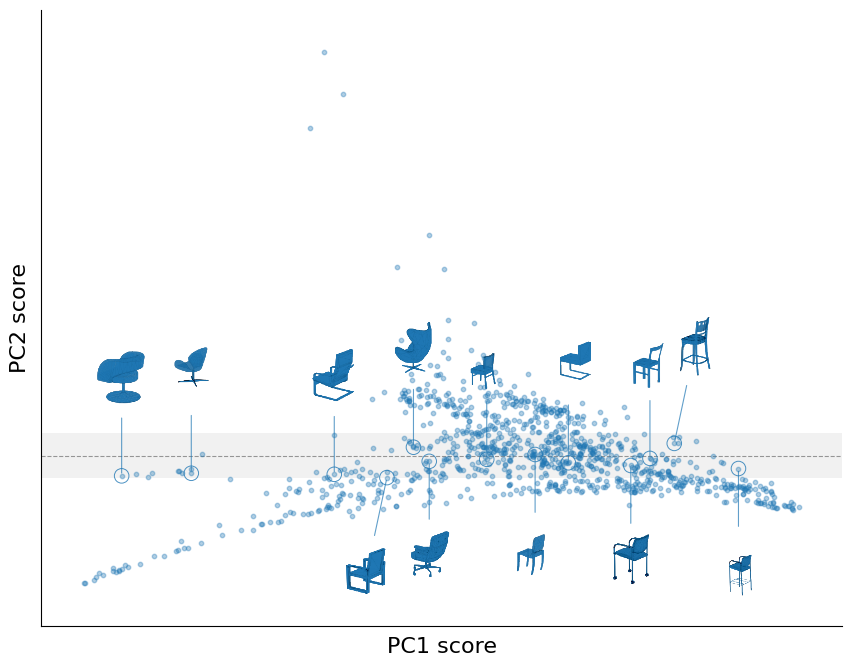

In [18]:
"""Plot GraphPCA PC1-PC2 with automatically selected PC1 examples.

Run this in the notebook/session that already defines:

    result, T_TO_PLOT, labels, CLASSES, class_cmap, paths, and load_off

The selector samples several PC1 quantiles. At each PC1 level it chooses an
actual chair whose PC2 and PC3 values are close to the center of the chair
distribution. This makes the thumbnails more suitable for interpreting PC1
than a manually selected collection of branch endpoints and outliers.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


# Configuration
RESULT_TO_PLOT = result
PC1_CATEGORY = "chair"

# Avoid the absolute endpoints, which are often unusual outliers.
PC1_QUANTILES = (
    0.075,
    0.20,
    0.35,
    0.50,
    0.65,
    0.80,
    0.85,
    0.95,
)

# For each quantile, first retain this fraction of chairs with the closest PC1
# values; then choose the one with the most central PC2 and PC3 values.
PC1_NEARBY_POOL_FRACTION = 0.005

THUMBNAIL_ZOOM = 0.4
THUMBNAIL_ELEVATION = 18
THUMBNAIL_AZIMUTH = 35
THUMBNAIL_OBJECT_ZOOM = 1.5

# Shade a horizontal strip around PC2 = 0. The half-width is expressed in
# standard deviations of PC2 among the chair candidates, so it adapts when
# the coefficient scale changes.
PC2_ZERO_STRIP_HALF_WIDTH_SD = 0.50
PC2_ZERO_STRIP_COLOR = "#d9d9d9"
PC2_ZERO_STRIP_ALPHA = 0.35
PC2_ZERO_LINE_COLOR = "#777777"

# Automatically selected thumbnails alternate above and below their points.
# Add entries here only when an individual thumbnail needs manual adjustment.
# First coordinate: horizontal displacement in points.
# Second coordinate: vertical displacement in points.
ADDITIONAL_THUMBNAIL_OBJECTS = [
    73, 181, 685, 166, 526,
]
MANUAL_THUMBNAIL_OFFSETS = {
    # object_index: (horizontal_offset, vertical_offset),
    73: (0, 70),
    181: (0, 70),
    685: (15, 70),
    166: (-15, -70),
    526: (0, 70),
}


# Label utilities
def class_object_indices(class_index, category):
    """Support integer-coded and category-name labels."""

    label_array = np.asarray(labels)

    if label_array.dtype.kind in {"U", "S"}:
        return np.flatnonzero(
            label_array.astype(str) == str(category)
        )

    if label_array.dtype.kind == "O":
        name_matches = np.flatnonzero(
            label_array.astype(str) == str(category)
        )

        if name_matches.size:
            return name_matches

    return np.flatnonzero(
        label_array == class_index
    )


def object_class_information(object_index):
    """Return the category and color index of one object."""

    raw_label = labels[object_index]

    if isinstance(raw_label, (int, np.integer)):
        class_index = int(raw_label)

        if not 0 <= class_index < len(CLASSES):
            raise ValueError(
                f"Invalid class label {class_index} "
                f"for object {object_index}."
            )

        category = CLASSES[class_index]

    else:
        category = str(raw_label)

        if category not in CLASSES:
            raise ValueError(
                f"Unknown category {category!r} "
                f"for object {object_index}."
            )

        class_index = list(CLASSES).index(category)

    return category, class_index


# Select representative chairs along PC1
def select_pc1_representatives(
    embedding,
    candidate_indices,
    quantiles=PC1_QUANTILES,
    pool_fraction=PC1_NEARBY_POOL_FRACTION,
):
    """Select chairs across PC1 while keeping PC2 and PC3 central.

    At every requested PC1 quantile, this function first creates a local pool
    of chairs with similar PC1 values. It then selects the chair whose other
    retained coordinates (PC2 and PC3 when available) are closest to their
    median values. Every selected chair is unique.
    """

    embedding = np.asarray(
        embedding,
        dtype=float,
    )
    candidate_indices = np.asarray(
        candidate_indices,
        dtype=int,
    )

    if embedding.ndim != 2 or embedding.shape[1] < 2:
        raise ValueError(
            "The embedding must contain at least PC1 and PC2."
        )
    if candidate_indices.size == 0:
        raise ValueError(
            "No candidate chairs were found."
        )
    if np.any(
        (candidate_indices < 0)
        | (candidate_indices >= len(embedding))
    ):
        raise IndexError(
            "candidate_indices contains an out-of-range index."
        )
    if len(quantiles) > len(candidate_indices):
        raise ValueError(
            "There are fewer candidate chairs than requested quantiles."
        )
    if not 0 < pool_fraction <= 1:
        raise ValueError(
            "pool_fraction must be in the interval (0, 1]."
        )

    quantiles = np.asarray(
        quantiles,
        dtype=float,
    )
    if np.any((quantiles <= 0) | (quantiles >= 1)):
        raise ValueError(
            "Use quantiles strictly between 0 and 1."
        )

    # Use PC2 and PC3 as controlled coordinates. If PC3 was not retained,
    # only PC2 is used.
    controlled_stop = min(3, embedding.shape[1])
    controlled_values = embedding[
        candidate_indices,
        1:controlled_stop,
    ]

    controlled_center = np.median(
        controlled_values,
        axis=0,
    )
    controlled_scale = np.std(
        controlled_values,
        axis=0,
    )
    controlled_scale = np.where(
        controlled_scale > np.finfo(float).eps,
        controlled_scale,
        1.0,
    )

    candidate_pc1 = embedding[
        candidate_indices,
        0,
    ]
    pc1_scale = max(
        float(np.std(candidate_pc1)),
        np.finfo(float).eps,
    )

    pool_size = max(
        20,
        int(np.ceil(
            pool_fraction * len(candidate_indices)
        )),
    )
    pool_size = min(
        pool_size,
        len(candidate_indices),
    )

    selected_indices = []
    selected_set = set()

    for quantile in quantiles:
        target_pc1 = np.quantile(
            candidate_pc1,
            quantile,
        )

        available = np.asarray([
            object_index
            for object_index in candidate_indices
            if int(object_index) not in selected_set
        ])

        pc1_distance = np.abs(
            embedding[available, 0] - target_pc1
        )
        nearby_order = np.argsort(pc1_distance)
        nearby = available[
            nearby_order[:min(pool_size, len(available))]
        ]

        standardized_controlled = (
            embedding[
                nearby,
                1:controlled_stop,
            ]
            - controlled_center
        ) / controlled_scale

        centrality_score = np.sum(
            standardized_controlled**2,
            axis=1,
        )

        # The local pool already enforces PC1 proximity. This small term only
        # breaks near-ties in favor of the exact requested PC1 quantile.
        pc1_target_error = (
            (
                embedding[nearby, 0]
                - target_pc1
            )
            / pc1_scale
        ) ** 2

        selection_score = (
            centrality_score
            + 0.05 * pc1_target_error
        )

        selected_object = int(
            nearby[np.argmin(selection_score)]
        )
        selected_indices.append(selected_object)
        selected_set.add(selected_object)

    return selected_indices


# Render one original ModelNet OFF mesh
def mesh_thumbnail(
    mesh_path,
    color,
    elevation=THUMBNAIL_ELEVATION,
    azimuth=THUMBNAIL_AZIMUTH,
    object_zoom=THUMBNAIL_OBJECT_ZOOM,
):
    """Render an original OFF mesh as a transparent image."""

    vertices, triangles = load_off(mesh_path)
    vertices = np.asarray(vertices, dtype=float)
    triangles = np.asarray(triangles, dtype=int)

    # Center and normalize the mesh.
    vertices = vertices - vertices.mean(
        axis=0,
        keepdims=True,
    )

    radius = np.linalg.norm(
        vertices,
        axis=1,
    ).max()

    if radius > np.finfo(float).eps:
        vertices = vertices / radius

    thumbnail_figure = plt.figure(
        figsize=(1.25, 1.25),
        dpi=100,
    )
    thumbnail_figure.patch.set_alpha(0.0)

    thumbnail_axis = thumbnail_figure.add_subplot(
        111,
        projection="3d",
    )
    thumbnail_axis.patch.set_alpha(0.0)

    mesh = Poly3DCollection(
        vertices[triangles],
        facecolors=color,
        edgecolors=(0, 0, 0, 0.10),
        linewidths=0.08,
        alpha=0.95,
    )
    thumbnail_axis.add_collection3d(mesh)

    # Use identical limits and camera settings for every thumbnail.
    thumbnail_axis.set_xlim(-1, 1)
    thumbnail_axis.set_ylim(-1, 1)
    thumbnail_axis.set_zlim(-1, 1)
    thumbnail_axis.set_box_aspect(
        (1, 1, 1),
        zoom=object_zoom,
    )
    thumbnail_axis.view_init(
        elev=elevation,
        azim=azimuth,
    )
    thumbnail_axis.set_axis_off()

    thumbnail_figure.subplots_adjust(
        left=0,
        right=1,
        bottom=0,
        top=1,
    )
    thumbnail_figure.canvas.draw()

    rgba = np.asarray(
        thumbnail_figure.canvas.buffer_rgba()
    ).copy()

    plt.close(thumbnail_figure)
    return rgba


# Extract the GraphPCA projection at the configured time
available_t_values = np.asarray(
    RESULT_TO_PLOT.t_values,
    dtype=float,
)

time_matches = np.flatnonzero(
    np.isclose(
        available_t_values,
        T_TO_PLOT,
        rtol=1e-12,
        atol=1e-12,
    )
)

if time_matches.size == 0:
    raise ValueError(
        f"t={T_TO_PLOT:g} was not fitted. "
        f"Available real times are "
        f"{RESULT_TO_PLOT.t_values}."
    )

time_index = int(time_matches[0])
time_key = RESULT_TO_PLOT.t_values[time_index]

embedding = np.asarray(
    RESULT_TO_PLOT.coeffs_dict[time_key],
    dtype=float,
)

if embedding.ndim != 2 or embedding.shape[1] < 2:
    raise ValueError(
        f"t={float(time_key):g} has fewer than two retained PCs."
    )
if len(embedding) != len(paths):
    raise ValueError(
        "The embedding and paths contain different numbers of objects."
    )
if len(labels) != len(paths):
    raise ValueError(
        "The labels and paths contain different numbers of objects."
    )

embedding_2d = embedding[:, :2]

print(
    f"Using real diffusion time t={float(time_key):g}"
)


# Select the PC1 representatives
if PC1_CATEGORY not in CLASSES:
    raise ValueError(
        f"Category {PC1_CATEGORY!r} is not present in CLASSES."
    )

chair_class_index = list(CLASSES).index(
    PC1_CATEGORY
)
chair_indices = class_object_indices(
    chair_class_index,
    PC1_CATEGORY,
)

THUMBNAIL_OBJECTS = select_pc1_representatives(
    embedding,
    chair_indices,
)

# Add manually requested thumbnails.
for object_index in ADDITIONAL_THUMBNAIL_OBJECTS:
    if not 0 <= object_index < len(paths):
        raise IndexError(
            f"Object index {object_index} is outside "
            f"the valid range 0–{len(paths) - 1}."
        )

    if object_index not in THUMBNAIL_OBJECTS:
        THUMBNAIL_OBJECTS.append(object_index)

# Create initial offsets for all thumbnails, including added ones.
THUMBNAIL_OFFSETS = {
    object_index: (
        0,
        70 if position % 2 == 0 else -70,
    )
    for position, object_index
    in enumerate(THUMBNAIL_OBJECTS)
}

# Apply your manual offset overrides.
THUMBNAIL_OFFSETS.update(
    MANUAL_THUMBNAIL_OFFSETS
)

print("Selected PC1 representatives:")
for quantile, object_index in zip(
    PC1_QUANTILES,
    THUMBNAIL_OBJECTS,
):
    pc3_text = (
        f"{embedding[object_index, 2]:+.6f}"
        if embedding.shape[1] >= 3
        else "not retained"
    )
    print(
        f"  q={quantile:0.2f}: object {object_index}, "
        f"PC1={embedding[object_index, 0]:+.6f}, "
        f"PC2={embedding[object_index, 1]:+.6f}, "
        f"PC3={pc3_text}, "
        f"file={Path(paths[object_index]).name}"
    )


# Draw the PC1-PC2 projection
fig, ax = plt.subplots(
    figsize=(9, 7)
)

# Show the central PC2 region behind the points. This visual guide highlights
# the region in which PC2 is close to zero; it is not an additional filter on
# the automatically selected thumbnails.
if PC2_ZERO_STRIP_HALF_WIDTH_SD < 0:
    raise ValueError(
        "PC2_ZERO_STRIP_HALF_WIDTH_SD must be nonnegative."
    )

chair_pc2_scale = float(np.std(
    embedding_2d[chair_indices, 1]
))
pc2_zero_strip_half_width = (
    PC2_ZERO_STRIP_HALF_WIDTH_SD
    * chair_pc2_scale
)

if pc2_zero_strip_half_width > np.finfo(float).eps:
    ax.axhspan(
        -pc2_zero_strip_half_width,
        pc2_zero_strip_half_width,
        facecolor=PC2_ZERO_STRIP_COLOR,
        alpha=PC2_ZERO_STRIP_ALPHA,
        edgecolor="none",
        zorder=0,
    )

ax.axhline(
    0.0,
    color=PC2_ZERO_LINE_COLOR,
    linewidth=0.8,
    linestyle="--",
    alpha=0.75,
    zorder=1,
)

for class_index, category in enumerate(CLASSES):
    object_indices = class_object_indices(
        class_index,
        category,
    )

    if object_indices.size == 0:
        continue

    ax.scatter(
        embedding_2d[object_indices, 0],
        embedding_2d[object_indices, 1],
        s=10,
        alpha=0.35,
        color=class_cmap(class_index),
        label=category.replace("_", " "),
        zorder=2,
    )



# Add thumbnails for the selected PC1 representatives
thumbnail_cache = {}

for object_index in THUMBNAIL_OBJECTS:
    _, class_index = object_class_information(
        object_index
    )
    color = class_cmap(class_index)

    thumbnail_cache[object_index] = mesh_thumbnail(
        paths[object_index],
        color,
    )

    image_box = OffsetImage(
        thumbnail_cache[object_index],
        zoom=THUMBNAIL_ZOOM,
    )

    annotation = AnnotationBbox(
        image_box,
        embedding_2d[object_index],
        xybox=THUMBNAIL_OFFSETS[object_index],
        xycoords="data",
        boxcoords="offset points",
        frameon=False,
        pad=0.1,
        arrowprops={
            "arrowstyle": "-",
            "color": color,
            "linewidth": 0.8,
            "alpha": 0.7,
        },
        annotation_clip=False,
        zorder=6,
    )
    ax.add_artist(annotation)

    # Highlight the corresponding point without displaying its index.
    ax.scatter(
        embedding_2d[object_index, 0],
        embedding_2d[object_index, 1],
        s=110,
        facecolors="none",
        edgecolors=color,
        linewidths=0.7,
        zorder=5,
        alpha=0.8,
    )



# Figure formatting and saving
FONT_SIZE = 16

x_values = embedding_2d[:, 0]
y_values = embedding_2d[:, 1]

x_range = np.ptp(x_values)
y_range = np.ptp(y_values)

x_padding = 0.06 * x_range
y_padding = 0.08 * y_range

ax.set_xlim(
    x_values.min() - x_padding,
    x_values.max() + x_padding,
)
ax.set_ylim(
    y_values.min() - y_padding,
    y_values.max() + y_padding,
)

ax.set_title(None)
ax.set_xlabel(
    "PC1 score",
    fontsize=FONT_SIZE,
    labelpad=8,
)
ax.set_ylabel(
    "PC2 score",
    fontsize=FONT_SIZE,
    labelpad=8,
)

# Preserve the axes but remove ticks and tick labels.
ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(
    axis="both",
    which="both",
    length=0,
)

# Keep only the left and bottom axes.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_linewidth(0.8)
ax.spines["left"].set_linewidth(0.8)

fig.subplots_adjust(
    left=0.10,
    right=0.99,
    bottom=0.11,
    top=0.99,
)

time_label = (
    f"{float(time_key):g}"
    .replace("-", "m")
    .replace(".", "p")
)

figure_path = Path(
    f"GraphPCA_t_{time_label}_"
    "PC1_representatives.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white",
)

print(f"Saved figure to: {figure_path.resolve()}")

plt.show()

Using real diffusion time t=10
Selected PC1 representatives:
  q=0.07: object 378, PC1=-0.008426, PC2=-0.001440, PC3=+0.000489, file=chair_0379.off
  q=0.20: object 851, PC1=-0.004204, PC2=-0.000442, PC3=-0.000219, file=chair_0852.off
  q=0.35: object 508, PC1=-0.001647, PC2=-0.000281, PC3=-0.000146, file=chair_0509.off
  q=0.50: object 444, PC1=+0.000504, PC2=+0.000087, PC3=-0.000117, file=chair_0445.off
  q=0.65: object 418, PC1=+0.001982, PC2=-0.000550, PC3=-0.000051, file=chair_0419.off
  q=0.80: object 736, PC1=+0.004758, PC2=-0.000759, PC3=+0.000024, file=chair_0737.off
  q=0.85: object 205, PC1=+0.005610, PC2=-0.000214, PC3=+0.000013, file=chair_0206.off
  q=0.95: object 171, PC1=+0.009545, PC2=-0.000995, PC3=+0.000399, file=chair_0172.off
Saved figure to: /content/GraphPCA_t_10_PC1_representatives_PC2_zero.png


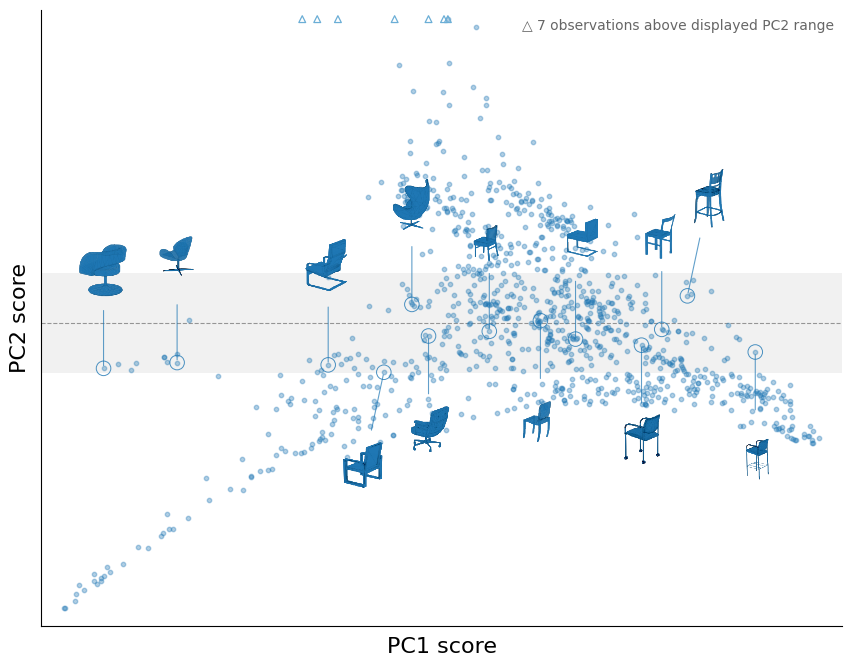

In [19]:
"""Plot GraphPCA PC1-PC2 with automatically selected PC1 examples.

Run this in the notebook/session that already defines:

    result, T_TO_PLOT, labels, CLASSES, class_cmap, paths, and load_off

The selector samples several PC1 quantiles. At each PC1 level it chooses an
actual chair whose PC2 and PC3 values are close to the center of the chair
distribution. This makes the thumbnails more suitable for interpreting PC1
than a manually selected collection of branch endpoints and outliers.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from mpl_toolkits.mplot3d.art3d import Poly3DCollection



# Configuration
RESULT_TO_PLOT = result
PC1_CATEGORY = "chair"

# Avoid the absolute endpoints, which are often unusual outliers.
PC1_QUANTILES = (
    0.075,
    0.20,
    0.35,
    0.50,
    0.65,
    0.80,
    0.85,
    0.95,
)

# For each quantile, first retain this fraction of chairs with the closest PC1
# values; then choose the one with the most central PC2 and PC3 values.
PC1_NEARBY_POOL_FRACTION = 0.005

THUMBNAIL_ZOOM = 0.4
THUMBNAIL_ELEVATION = 18
THUMBNAIL_AZIMUTH = 35
THUMBNAIL_OBJECT_ZOOM = 1.5

# Shade a horizontal strip around PC2 = 0. The half-width is expressed in
# standard deviations of PC2 among the chair candidates, so it adapts when
# the coefficient scale changes.
PC2_ZERO_STRIP_HALF_WIDTH_SD = 0.50
PC2_ZERO_STRIP_COLOR = "#d9d9d9"
PC2_ZERO_STRIP_ALPHA = 0.35
PC2_ZERO_LINE_COLOR = "#777777"

# Automatically selected thumbnails alternate above and below their points.
# Add entries here only when an individual thumbnail needs manual adjustment.
# First coordinate: horizontal displacement in points.
# Second coordinate: vertical displacement in points.
ADDITIONAL_THUMBNAIL_OBJECTS = [
    73, 181, 685, 166, 526,
]
MANUAL_THUMBNAIL_OFFSETS = {
    # object_index: (horizontal_offset, vertical_offset),
    73: (0, 70),
    181: (0, 70),
    685: (15, 70),
    166: (-15, -70),
    526: (0, 70),
}



# Label utilities
def class_object_indices(class_index, category):
    """Support integer-coded and category-name labels."""

    label_array = np.asarray(labels)

    if label_array.dtype.kind in {"U", "S"}:
        return np.flatnonzero(
            label_array.astype(str) == str(category)
        )

    if label_array.dtype.kind == "O":
        name_matches = np.flatnonzero(
            label_array.astype(str) == str(category)
        )

        if name_matches.size:
            return name_matches

    return np.flatnonzero(
        label_array == class_index
    )


def object_class_information(object_index):
    """Return the category and color index of one object."""

    raw_label = labels[object_index]

    if isinstance(raw_label, (int, np.integer)):
        class_index = int(raw_label)

        if not 0 <= class_index < len(CLASSES):
            raise ValueError(
                f"Invalid class label {class_index} "
                f"for object {object_index}."
            )

        category = CLASSES[class_index]

    else:
        category = str(raw_label)

        if category not in CLASSES:
            raise ValueError(
                f"Unknown category {category!r} "
                f"for object {object_index}."
            )

        class_index = list(CLASSES).index(category)

    return category, class_index



# Select representative chairs along PC1
def select_pc1_representatives(
    embedding,
    candidate_indices,
    quantiles=PC1_QUANTILES,
    pool_fraction=PC1_NEARBY_POOL_FRACTION,
):
    """Select chairs across PC1 while keeping PC2 and PC3 central.

    At every requested PC1 quantile, this function first creates a local pool
    of chairs with similar PC1 values. It then selects the chair whose other
    retained coordinates (PC2 and PC3 when available) are closest to their
    median values. Every selected chair is unique.
    """

    embedding = np.asarray(
        embedding,
        dtype=float,
    )
    candidate_indices = np.asarray(
        candidate_indices,
        dtype=int,
    )

    if embedding.ndim != 2 or embedding.shape[1] < 2:
        raise ValueError(
            "The embedding must contain at least PC1 and PC2."
        )
    if candidate_indices.size == 0:
        raise ValueError(
            "No candidate chairs were found."
        )
    if np.any(
        (candidate_indices < 0)
        | (candidate_indices >= len(embedding))
    ):
        raise IndexError(
            "candidate_indices contains an out-of-range index."
        )
    if len(quantiles) > len(candidate_indices):
        raise ValueError(
            "There are fewer candidate chairs than requested quantiles."
        )
    if not 0 < pool_fraction <= 1:
        raise ValueError(
            "pool_fraction must be in the interval (0, 1]."
        )

    quantiles = np.asarray(
        quantiles,
        dtype=float,
    )
    if np.any((quantiles <= 0) | (quantiles >= 1)):
        raise ValueError(
            "Use quantiles strictly between 0 and 1."
        )

    # Use PC2 and PC3 as controlled coordinates. If PC3 was not retained,
    # only PC2 is used.
    controlled_stop = min(3, embedding.shape[1])
    controlled_values = embedding[
        candidate_indices,
        1:controlled_stop,
    ]

    controlled_center = np.median(
        controlled_values,
        axis=0,
    )
    controlled_scale = np.std(
        controlled_values,
        axis=0,
    )
    controlled_scale = np.where(
        controlled_scale > np.finfo(float).eps,
        controlled_scale,
        1.0,
    )

    candidate_pc1 = embedding[
        candidate_indices,
        0,
    ]
    pc1_scale = max(
        float(np.std(candidate_pc1)),
        np.finfo(float).eps,
    )

    pool_size = max(
        20,
        int(np.ceil(
            pool_fraction * len(candidate_indices)
        )),
    )
    pool_size = min(
        pool_size,
        len(candidate_indices),
    )

    selected_indices = []
    selected_set = set()

    for quantile in quantiles:
        target_pc1 = np.quantile(
            candidate_pc1,
            quantile,
        )

        available = np.asarray([
            object_index
            for object_index in candidate_indices
            if int(object_index) not in selected_set
        ])

        pc1_distance = np.abs(
            embedding[available, 0] - target_pc1
        )
        nearby_order = np.argsort(pc1_distance)
        nearby = available[
            nearby_order[:min(pool_size, len(available))]
        ]

        standardized_controlled = (
            embedding[
                nearby,
                1:controlled_stop,
            ]
            - controlled_center
        ) / controlled_scale

        centrality_score = np.sum(
            standardized_controlled**2,
            axis=1,
        )

        # The local pool already enforces PC1 proximity. This small term only
        # breaks near-ties in favor of the exact requested PC1 quantile.
        pc1_target_error = (
            (
                embedding[nearby, 0]
                - target_pc1
            )
            / pc1_scale
        ) ** 2

        selection_score = (
            centrality_score
            + 0.05 * pc1_target_error
        )

        selected_object = int(
            nearby[np.argmin(selection_score)]
        )
        selected_indices.append(selected_object)
        selected_set.add(selected_object)

    return selected_indices



# Render one original ModelNet OFF mesh
def mesh_thumbnail(
    mesh_path,
    color,
    elevation=THUMBNAIL_ELEVATION,
    azimuth=THUMBNAIL_AZIMUTH,
    object_zoom=THUMBNAIL_OBJECT_ZOOM,
):
    """Render an original OFF mesh as a transparent image."""

    vertices, triangles = load_off(mesh_path)
    vertices = np.asarray(vertices, dtype=float)
    triangles = np.asarray(triangles, dtype=int)

    # Center and normalize the mesh.
    vertices = vertices - vertices.mean(
        axis=0,
        keepdims=True,
    )

    radius = np.linalg.norm(
        vertices,
        axis=1,
    ).max()

    if radius > np.finfo(float).eps:
        vertices = vertices / radius

    thumbnail_figure = plt.figure(
        figsize=(1.25, 1.25),
        dpi=100,
    )
    thumbnail_figure.patch.set_alpha(0.0)

    thumbnail_axis = thumbnail_figure.add_subplot(
        111,
        projection="3d",
    )
    thumbnail_axis.patch.set_alpha(0.0)

    mesh = Poly3DCollection(
        vertices[triangles],
        facecolors=color,
        edgecolors=(0, 0, 0, 0.10),
        linewidths=0.08,
        alpha=0.95,
    )
    thumbnail_axis.add_collection3d(mesh)

    # Use identical limits and camera settings for every thumbnail.
    thumbnail_axis.set_xlim(-1, 1)
    thumbnail_axis.set_ylim(-1, 1)
    thumbnail_axis.set_zlim(-1, 1)
    thumbnail_axis.set_box_aspect(
        (1, 1, 1),
        zoom=object_zoom,
    )
    thumbnail_axis.view_init(
        elev=elevation,
        azim=azimuth,
    )
    thumbnail_axis.set_axis_off()

    thumbnail_figure.subplots_adjust(
        left=0,
        right=1,
        bottom=0,
        top=1,
    )
    thumbnail_figure.canvas.draw()

    rgba = np.asarray(
        thumbnail_figure.canvas.buffer_rgba()
    ).copy()

    plt.close(thumbnail_figure)
    return rgba



# Extract the GraphPCA projection at the configured time


available_t_values = np.asarray(
    RESULT_TO_PLOT.t_values,
    dtype=float,
)

time_matches = np.flatnonzero(
    np.isclose(
        available_t_values,
        T_TO_PLOT,
        rtol=1e-12,
        atol=1e-12,
    )
)

if time_matches.size == 0:
    raise ValueError(
        f"t={T_TO_PLOT:g} was not fitted. "
        f"Available real times are "
        f"{RESULT_TO_PLOT.t_values}."
    )

time_index = int(time_matches[0])
time_key = RESULT_TO_PLOT.t_values[time_index]

embedding = np.asarray(
    RESULT_TO_PLOT.coeffs_dict[time_key],
    dtype=float,
)

if embedding.ndim != 2 or embedding.shape[1] < 2:
    raise ValueError(
        f"t={float(time_key):g} has fewer than two retained PCs."
    )
if len(embedding) != len(paths):
    raise ValueError(
        "The embedding and paths contain different numbers of objects."
    )
if len(labels) != len(paths):
    raise ValueError(
        "The labels and paths contain different numbers of objects."
    )

embedding_2d = embedding[:, :2]

print(
    f"Using real diffusion time t={float(time_key):g}"
)



# Select the PC1 representatives
if PC1_CATEGORY not in CLASSES:
    raise ValueError(
        f"Category {PC1_CATEGORY!r} is not present in CLASSES."
    )

chair_class_index = list(CLASSES).index(
    PC1_CATEGORY
)
chair_indices = class_object_indices(
    chair_class_index,
    PC1_CATEGORY,
)

THUMBNAIL_OBJECTS = select_pc1_representatives(
    embedding,
    chair_indices,
)

# Add manually requested thumbnails.
for object_index in ADDITIONAL_THUMBNAIL_OBJECTS:
    if not 0 <= object_index < len(paths):
        raise IndexError(
            f"Object index {object_index} is outside "
            f"the valid range 0–{len(paths) - 1}."
        )

    if object_index not in THUMBNAIL_OBJECTS:
        THUMBNAIL_OBJECTS.append(object_index)

# Create initial offsets for all thumbnails, including added ones.
THUMBNAIL_OFFSETS = {
    object_index: (
        0,
        70 if position % 2 == 0 else -70,
    )
    for position, object_index
    in enumerate(THUMBNAIL_OBJECTS)
}

# Apply your manual offset overrides.
THUMBNAIL_OFFSETS.update(
    MANUAL_THUMBNAIL_OFFSETS
)

print("Selected PC1 representatives:")
for quantile, object_index in zip(
    PC1_QUANTILES,
    THUMBNAIL_OBJECTS,
):
    pc3_text = (
        f"{embedding[object_index, 2]:+.6f}"
        if embedding.shape[1] >= 3
        else "not retained"
    )
    print(
        f"  q={quantile:0.2f}: object {object_index}, "
        f"PC1={embedding[object_index, 0]:+.6f}, "
        f"PC2={embedding[object_index, 1]:+.6f}, "
        f"PC3={pc3_text}, "
        f"file={Path(paths[object_index]).name}"
    )



# Draw the PC1-PC2 projection


fig, ax = plt.subplots(
    figsize=(9, 7)
)

# Show the central PC2 region behind the points. This visual guide highlights
# the region in which PC2 is close to zero; it is not an additional filter on
# the automatically selected thumbnails.
if PC2_ZERO_STRIP_HALF_WIDTH_SD < 0:
    raise ValueError(
        "PC2_ZERO_STRIP_HALF_WIDTH_SD must be nonnegative."
    )

chair_pc2_scale = float(np.std(
    embedding_2d[chair_indices, 1]
))
pc2_zero_strip_half_width = (
    PC2_ZERO_STRIP_HALF_WIDTH_SD
    * chair_pc2_scale
)

if pc2_zero_strip_half_width > np.finfo(float).eps:
    ax.axhspan(
        -pc2_zero_strip_half_width,
        pc2_zero_strip_half_width,
        facecolor=PC2_ZERO_STRIP_COLOR,
        alpha=PC2_ZERO_STRIP_ALPHA,
        edgecolor="none",
        zorder=0,
    )

ax.axhline(
    0.0,
    color=PC2_ZERO_LINE_COLOR,
    linewidth=0.8,
    linestyle="--",
    alpha=0.75,
    zorder=1,
)

for class_index, category in enumerate(CLASSES):
    object_indices = class_object_indices(
        class_index,
        category,
    )

    if object_indices.size == 0:
        continue

    ax.scatter(
        embedding_2d[object_indices, 0],
        embedding_2d[object_indices, 1],
        s=10,
        alpha=0.35,
        color=class_cmap(class_index),
        label=category.replace("_", " "),
        zorder=2,
    )



# Add thumbnails for the selected PC1 representatives
thumbnail_cache = {}

for object_index in THUMBNAIL_OBJECTS:
    _, class_index = object_class_information(
        object_index
    )
    color = class_cmap(class_index)

    thumbnail_cache[object_index] = mesh_thumbnail(
        paths[object_index],
        color,
    )

    image_box = OffsetImage(
        thumbnail_cache[object_index],
        zoom=THUMBNAIL_ZOOM,
    )

    annotation = AnnotationBbox(
        image_box,
        embedding_2d[object_index],
        xybox=THUMBNAIL_OFFSETS[object_index],
        xycoords="data",
        boxcoords="offset points",
        frameon=False,
        pad=0.1,
        arrowprops={
            "arrowstyle": "-",
            "color": color,
            "linewidth": 0.8,
            "alpha": 0.7,
        },
        annotation_clip=False,
        zorder=6,
    )
    ax.add_artist(annotation)

    # Highlight the corresponding point without displaying its index.
    ax.scatter(
        embedding_2d[object_index, 0],
        embedding_2d[object_index, 1],
        s=110,
        facecolors="none",
        edgecolors=color,
        linewidths=0.7,
        zorder=5,
        alpha=0.8,
    )



# Figure formatting and saving
FONT_SIZE = 16

x_values = embedding_2d[:, 0]
y_values = embedding_2d[:, 1]

x_range = np.ptp(x_values)
#y_range = np.ptp(y_values)

x_padding = 0.03 * x_range
#y_padding = 0.03 * y_range

ax.set_xlim(
    x_values.min() - x_padding,
    x_values.max() + x_padding,
)
#ax.set_ylim(
    #y_values.min() - y_padding,
    #y_values.max() + y_padding,
#)

#################################

# Keep the main PC2 cloud readable while indicating the three upper outliers.
N_UPPER_OUTLIERS = 7

y_order = np.argsort(y_values)
upper_outlier_indices = y_order[-N_UPPER_OUTLIERS:]
main_indices = y_order[:-N_UPPER_OUTLIERS]

main_y_values = y_values[main_indices]
main_y_range = np.ptp(main_y_values)
y_padding = 0.03 * main_y_range

y_lower = main_y_values.min() - y_padding
y_upper = main_y_values.max() + y_padding

ax.set_ylim(y_lower, y_upper)

# Mark the PC1 locations of observations lying above the displayed range.
outlier_marker_y = y_upper - 0.015 * (y_upper - y_lower)

ax.scatter(
    x_values[upper_outlier_indices],
    np.full(N_UPPER_OUTLIERS, outlier_marker_y),
    marker="^",
    s=24,
    facecolors="none",
    edgecolors="#6baed6",
    linewidths=0.9,
    clip_on=False,
    zorder=7,
)

ax.text(
    0.99,
    0.985,
    "△ 7 observations above displayed PC2 range",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    color="#666666",
)

#################################

ax.set_title(None)
ax.set_xlabel(
    "PC1 score",
    fontsize=FONT_SIZE,
    labelpad=8,
)
ax.set_ylabel(
    "PC2 score",
    fontsize=FONT_SIZE,
    labelpad=8,
)

# Preserve the axes but remove ticks and tick labels.
ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(
    axis="both",
    which="both",
    length=0,
)

# Keep only the left and bottom axes.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_linewidth(0.8)
ax.spines["left"].set_linewidth(0.8)

fig.subplots_adjust(
    left=0.10,
    right=0.99,
    bottom=0.11,
    top=0.99,
)

time_label = (
    f"{float(time_key):g}"
    .replace("-", "m")
    .replace(".", "p")
)

figure_path = Path(
    f"GraphPCA_t_{time_label}_"
    "PC1_representatives_PC2_zero.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white",
)

print(f"Saved figure to: {figure_path.resolve()}")

plt.show()

Using real diffusion time t=10
PC1 = 0 strip contains 177 of 989 chairs.
Selected PC2 representatives (bottom to top):
  q=0.10: object 304, PC1=-0.000210, PC2=-0.001647, PC3=-0.000126, file=chair_0305.off
  q=0.25: object 306, PC1=+0.000225, PC2=-0.000120, PC3=-0.000254, file=chair_0307.off
  q=0.40: object 174, PC1=+0.000401, PC2=+0.000357, PC3=-0.000183, file=chair_0175.off
  q=0.50: object 245, PC1=-0.000183, PC2=+0.000562, PC3=-0.000222, file=chair_0246.off
  q=0.60: object 950, PC1=-0.000034, PC2=+0.002124, PC3=-0.000152, file=chair_0951.off
  q=0.75: object 581, PC1=-0.000126, PC2=+0.003320, PC3=-0.000227, file=chair_0582.off
  q=0.90: object 382, PC1=-0.000133, PC2=+0.004206, PC3=-0.000198, file=chair_0383.off
Saved figure to: /content/GraphPCA_t_10_PC2_representatives.png


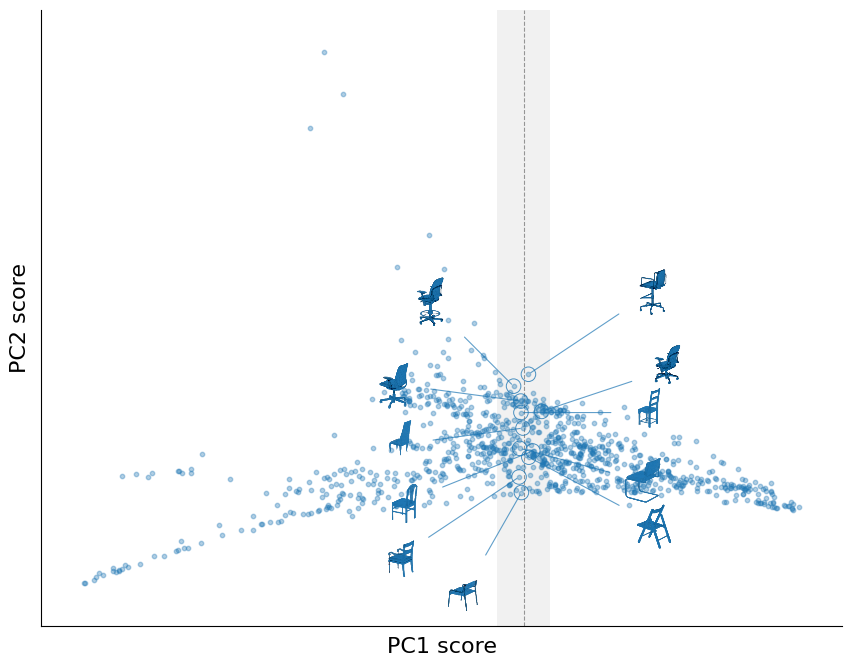

In [20]:
"""Show the PC2 pattern in a PC1-PC2 projection.

Run this cell/file in the notebook session that already defines:

    result, T_TO_PLOT, labels, CLASSES, class_cmap, paths, and load_off

PC1 is horizontal and PC2 is vertical. The shaded vertical strip is centered
at PC1 = 0. Representative chairs are chosen from bottom to top across PC2,
using only chairs inside that strip and preferring chairs close to PC1 = 0
with central PC3 values.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from mpl_toolkits.mplot3d.art3d import Poly3DCollection



# Configuration
RESULT_TO_PLOT = result
TARGET_CATEGORY = "chair"

# Seven positions from low to high PC2. Avoid the absolute endpoints because
# they are often isolated or unusual models rather than representative chairs.
PC2_QUANTILES = (
    0.10,
    0.25,
    0.40,
    0.50,
    0.60,
    0.75,
    0.90,
)

# At each PC2 target, form a nearby pool and then prefer the model closest to
# PC1 = 0 whose PC3 is also close to the center of the candidate set.
PC2_NEARBY_POOL_FRACTION = 0.05

# Keep automatic representatives within PC1 = 0 plus or minus this number of
# chair-PC1 standard deviations. This interval is also drawn as the strip.
PC1_ZERO_STRIP_HALF_WIDTH_SD = 0.20
PC1_ZERO_STRIP_COLOR = "#d9d9d9"
PC1_ZERO_STRIP_ALPHA = 0.35
PC1_ZERO_LINE_COLOR = "#777777"

THUMBNAIL_ZOOM = 0.35
THUMBNAIL_ELEVATION = 18
THUMBNAIL_AZIMUTH = 35
THUMBNAIL_OBJECT_ZOOM = 1.5

# Optional extra objects. These are added after the automatic examples and
# do not have to lie inside the PC1 = 0 strip.
ADDITIONAL_THUMBNAIL_OBJECTS = [
    948, 377, 568, 585,
]

# First value: horizontal displacement in points.
# Second value: vertical displacement in points.
MANUAL_THUMBNAIL_OFFSETS = {
    948: (90, 60),
    377: (-40, -70),
    568: (90, 30),
    585: (-60, 60),
}



# Label utilities
def class_object_indices(class_index, category):
    """Support integer-coded and category-name labels."""

    label_array = np.asarray(labels)

    if label_array.dtype.kind in {"U", "S"}:
        return np.flatnonzero(
            label_array.astype(str) == str(category)
        )

    if label_array.dtype.kind == "O":
        name_matches = np.flatnonzero(
            label_array.astype(str) == str(category)
        )
        if name_matches.size:
            return name_matches

    return np.flatnonzero(label_array == class_index)


def object_class_information(object_index):
    """Return the category and color index of one object."""

    raw_label = labels[object_index]

    if isinstance(raw_label, (int, np.integer)):
        class_index = int(raw_label)
        if not 0 <= class_index < len(CLASSES):
            raise ValueError(
                f"Invalid class label {class_index} "
                f"for object {object_index}."
            )
        category = CLASSES[class_index]
    else:
        category = str(raw_label)
        if category not in CLASSES:
            raise ValueError(
                f"Unknown category {category!r} "
                f"for object {object_index}."
            )
        class_index = list(CLASSES).index(category)

    return category, class_index



# Select representative chairs from bottom to top along PC2
def select_pc2_representatives(
    embedding,
    candidate_indices,
    quantiles=PC2_QUANTILES,
    pool_fraction=PC2_NEARBY_POOL_FRACTION,
):
    """Select chairs across PC2 while keeping PC1 near zero and PC3 central."""

    embedding = np.asarray(embedding, dtype=float)
    candidate_indices = np.asarray(candidate_indices, dtype=int)
    quantiles = np.asarray(quantiles, dtype=float)

    if embedding.ndim != 2 or embedding.shape[1] < 3:
        raise ValueError(
            "Selecting PC2 examples while controlling PC3 requires "
            "at least three retained PCs."
        )
    if candidate_indices.size == 0:
        raise ValueError(
            "No chair candidates remain inside the PC1 = 0 strip. "
            "Increase PC1_ZERO_STRIP_HALF_WIDTH_SD."
        )
    if np.any(
        (candidate_indices < 0)
        | (candidate_indices >= len(embedding))
    ):
        raise IndexError(
            "candidate_indices contains an out-of-range index."
        )
    if len(quantiles) > len(candidate_indices):
        raise ValueError(
            "There are fewer candidate chairs than requested quantiles."
        )
    if np.any((quantiles <= 0) | (quantiles >= 1)):
        raise ValueError(
            "Use quantiles strictly between 0 and 1."
        )
    if not 0 < pool_fraction <= 1:
        raise ValueError(
            "pool_fraction must be in the interval (0, 1]."
        )

    candidate_pc2 = embedding[candidate_indices, 1]
    candidate_pc3 = embedding[candidate_indices, 2]

    pc1_scale = max(
        float(np.std(embedding[candidate_indices, 0])),
        np.finfo(float).eps,
    )
    pc3_center = float(np.median(candidate_pc3))
    pc3_scale = max(
        float(np.std(candidate_pc3)),
        np.finfo(float).eps,
    )
    pc2_scale = max(
        float(np.std(candidate_pc2)),
        np.finfo(float).eps,
    )

    pool_size = max(
        20,
        int(np.ceil(
            pool_fraction * len(candidate_indices)
        )),
    )
    pool_size = min(pool_size, len(candidate_indices))

    selected_indices = []
    selected_set = set()

    for quantile in quantiles:
        target_pc2 = float(np.quantile(
            candidate_pc2,
            quantile,
        ))

        available = np.asarray([
            object_index
            for object_index in candidate_indices
            if int(object_index) not in selected_set
        ])

        pc2_distance = np.abs(
            embedding[available, 1] - target_pc2
        )
        nearby_order = np.argsort(pc2_distance)
        nearby = available[
            nearby_order[:min(pool_size, len(available))]
        ]

        # PC2 proximity defines the local pool. Within it, favor PC1 near
        # zero and a central PC3 value, making the thumbnails a cleaner
        # visual comparison of changes along PC2.
        pc1_zero_distance = (
            embedding[nearby, 0] / pc1_scale
        ) ** 2
        pc3_centrality = (
            (embedding[nearby, 2] - pc3_center)
            / pc3_scale
        ) ** 2
        pc2_target_error = (
            (embedding[nearby, 1] - target_pc2)
            / pc2_scale
        ) ** 2

        selection_score = (
            pc1_zero_distance
            + pc3_centrality
            + 0.05 * pc2_target_error
        )

        selected_object = int(
            nearby[np.argmin(selection_score)]
        )
        selected_indices.append(selected_object)
        selected_set.add(selected_object)

    return selected_indices



# Render one original ModelNet OFF mesh
def mesh_thumbnail(
    mesh_path,
    color,
    elevation=THUMBNAIL_ELEVATION,
    azimuth=THUMBNAIL_AZIMUTH,
    object_zoom=THUMBNAIL_OBJECT_ZOOM,
):
    """Render an original OFF mesh as a transparent image."""

    vertices, triangles = load_off(mesh_path)
    vertices = np.asarray(vertices, dtype=float)
    triangles = np.asarray(triangles, dtype=int)

    vertices = vertices - vertices.mean(
        axis=0,
        keepdims=True,
    )
    radius = np.linalg.norm(vertices, axis=1).max()
    if radius > np.finfo(float).eps:
        vertices = vertices / radius

    thumbnail_figure = plt.figure(
        figsize=(1.25, 1.25),
        dpi=100,
    )
    thumbnail_figure.patch.set_alpha(0.0)

    thumbnail_axis = thumbnail_figure.add_subplot(
        111,
        projection="3d",
    )
    thumbnail_axis.patch.set_alpha(0.0)

    mesh = Poly3DCollection(
        vertices[triangles],
        facecolors=color,
        edgecolors=(0, 0, 0, 0.10),
        linewidths=0.08,
        alpha=0.95,
    )
    thumbnail_axis.add_collection3d(mesh)

    thumbnail_axis.set_xlim(-1, 1)
    thumbnail_axis.set_ylim(-1, 1)
    thumbnail_axis.set_zlim(-1, 1)
    thumbnail_axis.set_box_aspect(
        (1, 1, 1),
        zoom=object_zoom,
    )
    thumbnail_axis.view_init(
        elev=elevation,
        azim=azimuth,
    )
    thumbnail_axis.set_axis_off()

    thumbnail_figure.subplots_adjust(
        left=0,
        right=1,
        bottom=0,
        top=1,
    )
    thumbnail_figure.canvas.draw()

    rgba = np.asarray(
        thumbnail_figure.canvas.buffer_rgba()
    ).copy()

    plt.close(thumbnail_figure)
    return rgba



# Extract the GraphPCA coefficients at the configured time


available_t_values = np.asarray(
    RESULT_TO_PLOT.t_values,
    dtype=float,
)

time_matches = np.flatnonzero(
    np.isclose(
        available_t_values,
        T_TO_PLOT,
        rtol=1e-12,
        atol=1e-12,
    )
)

if time_matches.size == 0:
    raise ValueError(
        f"t={T_TO_PLOT:g} was not fitted. "
        f"Available real times are "
        f"{RESULT_TO_PLOT.t_values}."
    )

time_index = int(time_matches[0])
time_key = RESULT_TO_PLOT.t_values[time_index]

embedding = np.asarray(
    RESULT_TO_PLOT.coeffs_dict[time_key],
    dtype=float,
)

if embedding.ndim != 2 or embedding.shape[1] < 3:
    raise ValueError(
        f"t={float(time_key):g} has fewer than three retained PCs."
    )
if len(embedding) != len(paths):
    raise ValueError(
        "The embedding and paths contain different numbers of objects."
    )
if len(labels) != len(paths):
    raise ValueError(
        "The labels and paths contain different numbers of objects."
    )

# PC1 is horizontal and PC2 is vertical.
embedding_2d = embedding[:, :2]

print(f"Using real diffusion time t={float(time_key):g}")



# Restrict candidates to PC1 = 0 and select from low to high PC2
if TARGET_CATEGORY not in CLASSES:
    raise ValueError(
        f"Category {TARGET_CATEGORY!r} is not present in CLASSES."
    )

chair_class_index = list(CLASSES).index(TARGET_CATEGORY)
chair_indices = class_object_indices(
    chair_class_index,
    TARGET_CATEGORY,
)

if PC1_ZERO_STRIP_HALF_WIDTH_SD < 0:
    raise ValueError(
        "PC1_ZERO_STRIP_HALF_WIDTH_SD must be nonnegative."
    )

chair_pc1_scale = float(np.std(
    embedding[chair_indices, 0]
))
pc1_zero_strip_half_width = (
    PC1_ZERO_STRIP_HALF_WIDTH_SD
    * chair_pc1_scale
)

pc2_candidate_indices = chair_indices[
    np.abs(embedding[chair_indices, 0])
    <= pc1_zero_strip_half_width
]

print(
    f"PC1 = 0 strip contains {len(pc2_candidate_indices)} "
    f"of {len(chair_indices)} chairs."
)

THUMBNAIL_OBJECTS = select_pc2_representatives(
    embedding,
    pc2_candidate_indices,
)

for object_index in ADDITIONAL_THUMBNAIL_OBJECTS:
    if not 0 <= object_index < len(paths):
        raise IndexError(
            f"Object index {object_index} is outside "
            f"the valid range 0-{len(paths) - 1}."
        )
    if object_index not in THUMBNAIL_OBJECTS:
        THUMBNAIL_OBJECTS.append(object_index)

# Spread thumbnails vertically while alternating left and right.
vertical_offsets = np.linspace(
    -60,
    60,
    len(THUMBNAIL_OBJECTS),
)

THUMBNAIL_OFFSETS = {
    object_index: (
        -90 if position % 2 == 0 else 90,
        vertical_offsets[position],
    )
    for position, object_index
    in enumerate(THUMBNAIL_OBJECTS)
}

THUMBNAIL_OFFSETS.update(MANUAL_THUMBNAIL_OFFSETS)

print("Selected PC2 representatives (bottom to top):")
for quantile, object_index in zip(
    PC2_QUANTILES,
    THUMBNAIL_OBJECTS,
):
    print(
        f"  q={quantile:0.2f}: object {object_index}, "
        f"PC1={embedding[object_index, 0]:+.6f}, "
        f"PC2={embedding[object_index, 1]:+.6f}, "
        f"PC3={embedding[object_index, 2]:+.6f}, "
        f"file={Path(paths[object_index]).name}"
    )



# Draw the PC1-PC2 projection
fig, ax = plt.subplots(figsize=(9, 7))

if pc1_zero_strip_half_width > np.finfo(float).eps:
    ax.axvspan(
        -pc1_zero_strip_half_width,
        pc1_zero_strip_half_width,
        facecolor=PC1_ZERO_STRIP_COLOR,
        alpha=PC1_ZERO_STRIP_ALPHA,
        edgecolor="none",
        zorder=0,
    )

ax.axvline(
    0.0,
    color=PC1_ZERO_LINE_COLOR,
    linewidth=0.8,
    linestyle="--",
    alpha=0.75,
    zorder=1,
)

for class_index, category in enumerate(CLASSES):
    object_indices = class_object_indices(
        class_index,
        category,
    )
    if object_indices.size == 0:
        continue

    ax.scatter(
        embedding_2d[object_indices, 0],
        embedding_2d[object_indices, 1],
        s=10,
        alpha=0.35,
        color=class_cmap(class_index),
        label=category.replace("_", " "),
        zorder=2,
    )



# Add thumbnails for the selected PC2 representatives
thumbnail_cache = {}

for object_index in THUMBNAIL_OBJECTS:
    _, class_index = object_class_information(object_index)
    color = class_cmap(class_index)

    thumbnail_cache[object_index] = mesh_thumbnail(
        paths[object_index],
        color,
    )
    image_box = OffsetImage(
        thumbnail_cache[object_index],
        zoom=THUMBNAIL_ZOOM,
    )

    annotation = AnnotationBbox(
        image_box,
        embedding_2d[object_index],
        xybox=THUMBNAIL_OFFSETS[object_index],
        xycoords="data",
        boxcoords="offset points",
        frameon=False,
        pad=0.1,
        arrowprops={
            "arrowstyle": "-",
            "color": color,
            "linewidth": 0.8,
            "alpha": 0.7,
        },
        annotation_clip=False,
        zorder=6,
    )
    ax.add_artist(annotation)

    ax.scatter(
        embedding_2d[object_index, 0],
        embedding_2d[object_index, 1],
        s=110,
        facecolors="none",
        edgecolors=color,
        linewidths=0.7,
        zorder=5,
        alpha=0.8,
    )



# Figure formatting and saving
FONT_SIZE = 16

x_values = embedding_2d[:, 0]
y_values = embedding_2d[:, 1]
x_range = np.ptp(x_values)
y_range = np.ptp(y_values)

x_padding = 0.06 * x_range
y_padding = 0.08 * y_range

ax.set_xlim(
    x_values.min() - x_padding,
    x_values.max() + x_padding,
)
ax.set_ylim(
    y_values.min() - y_padding,
    y_values.max() + y_padding,
)

ax.set_title(None)
ax.set_xlabel(
    "PC1 score",
    fontsize=FONT_SIZE,
    labelpad=8,
)
ax.set_ylabel(
    "PC2 score",
    fontsize=FONT_SIZE,
    labelpad=8,
)

ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(
    axis="both",
    which="both",
    length=0,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_linewidth(0.8)
ax.spines["left"].set_linewidth(0.8)

fig.subplots_adjust(
    left=0.10,
    right=0.99,
    bottom=0.11,
    top=0.99,
)

time_label = (
    f"{float(time_key):g}"
    .replace("-", "m")
    .replace(".", "p")
)

figure_path = Path(
    f"GraphPCA_t_{time_label}_"
    "PC2_representatives.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white",
)

print(f"Saved figure to: {figure_path.resolve()}")

plt.show()

Using real diffusion time t=10
PC1 = 0 strip contains 177 of 989 chairs.
Selected PC2 representatives (bottom to top):
  q=0.10: object 304, PC1=-0.000210, PC2=-0.001647, PC3=-0.000126, file=chair_0305.off
  q=0.25: object 306, PC1=+0.000225, PC2=-0.000120, PC3=-0.000254, file=chair_0307.off
  q=0.40: object 174, PC1=+0.000401, PC2=+0.000357, PC3=-0.000183, file=chair_0175.off
  q=0.50: object 245, PC1=-0.000183, PC2=+0.000562, PC3=-0.000222, file=chair_0246.off
  q=0.60: object 950, PC1=-0.000034, PC2=+0.002124, PC3=-0.000152, file=chair_0951.off
  q=0.75: object 581, PC1=-0.000126, PC2=+0.003320, PC3=-0.000227, file=chair_0582.off
  q=0.90: object 382, PC1=-0.000133, PC2=+0.004206, PC3=-0.000198, file=chair_0383.off
Saved figure to: /content/GraphPCA_t_10_PC2_representatives_PC1_zero.png


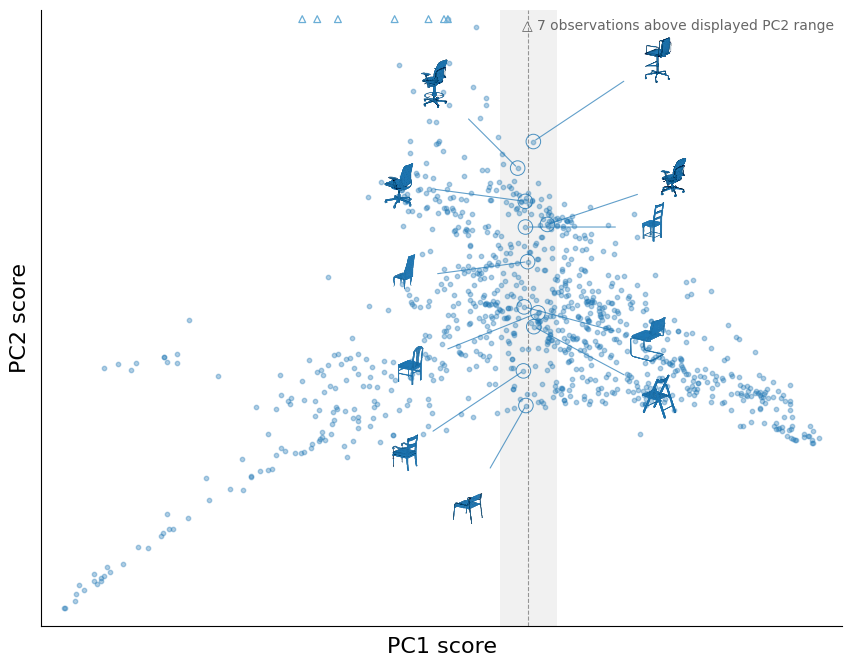

In [21]:
"""Show the PC2 pattern in a PC1-PC2 projection.

Run this cell/file in the notebook session that already defines:

    result, T_TO_PLOT, labels, CLASSES, class_cmap, paths, and load_off

PC1 is horizontal and PC2 is vertical. The shaded vertical strip is centered
at PC1 = 0. Representative chairs are chosen from bottom to top across PC2,
using only chairs inside that strip and preferring chairs close to PC1 = 0
with central PC3 values.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from mpl_toolkits.mplot3d.art3d import Poly3DCollection



# Configuration
RESULT_TO_PLOT = result
TARGET_CATEGORY = "chair"

# Seven positions from low to high PC2. Avoid the absolute endpoints because
# they are often isolated or unusual models rather than representative chairs.
PC2_QUANTILES = (
    0.10,
    0.25,
    0.40,
    0.50,
    0.60,
    0.75,
    0.90,
)

# At each PC2 target, form a nearby pool and then prefer the model closest to
# PC1 = 0 whose PC3 is also close to the center of the candidate set.
PC2_NEARBY_POOL_FRACTION = 0.05

# Keep automatic representatives within PC1 = 0 plus or minus this number of
# chair-PC1 standard deviations. This interval is also drawn as the strip.
PC1_ZERO_STRIP_HALF_WIDTH_SD = 0.20
PC1_ZERO_STRIP_COLOR = "#d9d9d9"
PC1_ZERO_STRIP_ALPHA = 0.35
PC1_ZERO_LINE_COLOR = "#777777"

THUMBNAIL_ZOOM = 0.35
THUMBNAIL_ELEVATION = 18
THUMBNAIL_AZIMUTH = 35
THUMBNAIL_OBJECT_ZOOM = 1.5

# Optional extra objects. These are added after the automatic examples and
# do not have to lie inside the PC1 = 0 strip.
ADDITIONAL_THUMBNAIL_OBJECTS = [
    948, 377, 568, 585,
]

# First value: horizontal displacement in points.
# Second value: vertical displacement in points.
MANUAL_THUMBNAIL_OFFSETS = {
    948: (90, 60),
    377: (-40, -70),
    568: (90, 30),
    585: (-60, 60),
}



# Label utilities


def class_object_indices(class_index, category):
    """Support integer-coded and category-name labels."""

    label_array = np.asarray(labels)

    if label_array.dtype.kind in {"U", "S"}:
        return np.flatnonzero(
            label_array.astype(str) == str(category)
        )

    if label_array.dtype.kind == "O":
        name_matches = np.flatnonzero(
            label_array.astype(str) == str(category)
        )
        if name_matches.size:
            return name_matches

    return np.flatnonzero(label_array == class_index)


def object_class_information(object_index):
    """Return the category and color index of one object."""

    raw_label = labels[object_index]

    if isinstance(raw_label, (int, np.integer)):
        class_index = int(raw_label)
        if not 0 <= class_index < len(CLASSES):
            raise ValueError(
                f"Invalid class label {class_index} "
                f"for object {object_index}."
            )
        category = CLASSES[class_index]
    else:
        category = str(raw_label)
        if category not in CLASSES:
            raise ValueError(
                f"Unknown category {category!r} "
                f"for object {object_index}."
            )
        class_index = list(CLASSES).index(category)

    return category, class_index



# Select representative chairs from bottom to top along PC2


def select_pc2_representatives(
    embedding,
    candidate_indices,
    quantiles=PC2_QUANTILES,
    pool_fraction=PC2_NEARBY_POOL_FRACTION,
):
    """Select chairs across PC2 while keeping PC1 near zero and PC3 central."""

    embedding = np.asarray(embedding, dtype=float)
    candidate_indices = np.asarray(candidate_indices, dtype=int)
    quantiles = np.asarray(quantiles, dtype=float)

    if embedding.ndim != 2 or embedding.shape[1] < 3:
        raise ValueError(
            "Selecting PC2 examples while controlling PC3 requires "
            "at least three retained PCs."
        )
    if candidate_indices.size == 0:
        raise ValueError(
            "No chair candidates remain inside the PC1 = 0 strip. "
            "Increase PC1_ZERO_STRIP_HALF_WIDTH_SD."
        )
    if np.any(
        (candidate_indices < 0)
        | (candidate_indices >= len(embedding))
    ):
        raise IndexError(
            "candidate_indices contains an out-of-range index."
        )
    if len(quantiles) > len(candidate_indices):
        raise ValueError(
            "There are fewer candidate chairs than requested quantiles."
        )
    if np.any((quantiles <= 0) | (quantiles >= 1)):
        raise ValueError(
            "Use quantiles strictly between 0 and 1."
        )
    if not 0 < pool_fraction <= 1:
        raise ValueError(
            "pool_fraction must be in the interval (0, 1]."
        )

    candidate_pc2 = embedding[candidate_indices, 1]
    candidate_pc3 = embedding[candidate_indices, 2]

    pc1_scale = max(
        float(np.std(embedding[candidate_indices, 0])),
        np.finfo(float).eps,
    )
    pc3_center = float(np.median(candidate_pc3))
    pc3_scale = max(
        float(np.std(candidate_pc3)),
        np.finfo(float).eps,
    )
    pc2_scale = max(
        float(np.std(candidate_pc2)),
        np.finfo(float).eps,
    )

    pool_size = max(
        20,
        int(np.ceil(
            pool_fraction * len(candidate_indices)
        )),
    )
    pool_size = min(pool_size, len(candidate_indices))

    selected_indices = []
    selected_set = set()

    for quantile in quantiles:
        target_pc2 = float(np.quantile(
            candidate_pc2,
            quantile,
        ))

        available = np.asarray([
            object_index
            for object_index in candidate_indices
            if int(object_index) not in selected_set
        ])

        pc2_distance = np.abs(
            embedding[available, 1] - target_pc2
        )
        nearby_order = np.argsort(pc2_distance)
        nearby = available[
            nearby_order[:min(pool_size, len(available))]
        ]

        # PC2 proximity defines the local pool. Within it, favor PC1 near
        # zero and a central PC3 value, making the thumbnails a cleaner
        # visual comparison of changes along PC2.
        pc1_zero_distance = (
            embedding[nearby, 0] / pc1_scale
        ) ** 2
        pc3_centrality = (
            (embedding[nearby, 2] - pc3_center)
            / pc3_scale
        ) ** 2
        pc2_target_error = (
            (embedding[nearby, 1] - target_pc2)
            / pc2_scale
        ) ** 2

        selection_score = (
            pc1_zero_distance
            + pc3_centrality
            + 0.05 * pc2_target_error
        )

        selected_object = int(
            nearby[np.argmin(selection_score)]
        )
        selected_indices.append(selected_object)
        selected_set.add(selected_object)

    return selected_indices



# Render one original ModelNet OFF mesh
def mesh_thumbnail(
    mesh_path,
    color,
    elevation=THUMBNAIL_ELEVATION,
    azimuth=THUMBNAIL_AZIMUTH,
    object_zoom=THUMBNAIL_OBJECT_ZOOM,
):
    """Render an original OFF mesh as a transparent image."""

    vertices, triangles = load_off(mesh_path)
    vertices = np.asarray(vertices, dtype=float)
    triangles = np.asarray(triangles, dtype=int)

    vertices = vertices - vertices.mean(
        axis=0,
        keepdims=True,
    )
    radius = np.linalg.norm(vertices, axis=1).max()
    if radius > np.finfo(float).eps:
        vertices = vertices / radius

    thumbnail_figure = plt.figure(
        figsize=(1.25, 1.25),
        dpi=100,
    )
    thumbnail_figure.patch.set_alpha(0.0)

    thumbnail_axis = thumbnail_figure.add_subplot(
        111,
        projection="3d",
    )
    thumbnail_axis.patch.set_alpha(0.0)

    mesh = Poly3DCollection(
        vertices[triangles],
        facecolors=color,
        edgecolors=(0, 0, 0, 0.10),
        linewidths=0.08,
        alpha=0.95,
    )
    thumbnail_axis.add_collection3d(mesh)

    thumbnail_axis.set_xlim(-1, 1)
    thumbnail_axis.set_ylim(-1, 1)
    thumbnail_axis.set_zlim(-1, 1)
    thumbnail_axis.set_box_aspect(
        (1, 1, 1),
        zoom=object_zoom,
    )
    thumbnail_axis.view_init(
        elev=elevation,
        azim=azimuth,
    )
    thumbnail_axis.set_axis_off()

    thumbnail_figure.subplots_adjust(
        left=0,
        right=1,
        bottom=0,
        top=1,
    )
    thumbnail_figure.canvas.draw()

    rgba = np.asarray(
        thumbnail_figure.canvas.buffer_rgba()
    ).copy()

    plt.close(thumbnail_figure)
    return rgba



# Extract the GraphPCA coefficients at the configured time
available_t_values = np.asarray(
    RESULT_TO_PLOT.t_values,
    dtype=float,
)

time_matches = np.flatnonzero(
    np.isclose(
        available_t_values,
        T_TO_PLOT,
        rtol=1e-12,
        atol=1e-12,
    )
)

if time_matches.size == 0:
    raise ValueError(
        f"t={T_TO_PLOT:g} was not fitted. "
        f"Available real times are "
        f"{RESULT_TO_PLOT.t_values}."
    )

time_index = int(time_matches[0])
time_key = RESULT_TO_PLOT.t_values[time_index]

embedding = np.asarray(
    RESULT_TO_PLOT.coeffs_dict[time_key],
    dtype=float,
)

if embedding.ndim != 2 or embedding.shape[1] < 3:
    raise ValueError(
        f"t={float(time_key):g} has fewer than three retained PCs."
    )
if len(embedding) != len(paths):
    raise ValueError(
        "The embedding and paths contain different numbers of objects."
    )
if len(labels) != len(paths):
    raise ValueError(
        "The labels and paths contain different numbers of objects."
    )

# PC1 is horizontal and PC2 is vertical.
embedding_2d = embedding[:, :2]

print(f"Using real diffusion time t={float(time_key):g}")



# Restrict candidates to PC1 = 0 and select from low to high PC2
if TARGET_CATEGORY not in CLASSES:
    raise ValueError(
        f"Category {TARGET_CATEGORY!r} is not present in CLASSES."
    )

chair_class_index = list(CLASSES).index(TARGET_CATEGORY)
chair_indices = class_object_indices(
    chair_class_index,
    TARGET_CATEGORY,
)

if PC1_ZERO_STRIP_HALF_WIDTH_SD < 0:
    raise ValueError(
        "PC1_ZERO_STRIP_HALF_WIDTH_SD must be nonnegative."
    )

chair_pc1_scale = float(np.std(
    embedding[chair_indices, 0]
))
pc1_zero_strip_half_width = (
    PC1_ZERO_STRIP_HALF_WIDTH_SD
    * chair_pc1_scale
)

pc2_candidate_indices = chair_indices[
    np.abs(embedding[chair_indices, 0])
    <= pc1_zero_strip_half_width
]

print(
    f"PC1 = 0 strip contains {len(pc2_candidate_indices)} "
    f"of {len(chair_indices)} chairs."
)

THUMBNAIL_OBJECTS = select_pc2_representatives(
    embedding,
    pc2_candidate_indices,
)

for object_index in ADDITIONAL_THUMBNAIL_OBJECTS:
    if not 0 <= object_index < len(paths):
        raise IndexError(
            f"Object index {object_index} is outside "
            f"the valid range 0-{len(paths) - 1}."
        )
    if object_index not in THUMBNAIL_OBJECTS:
        THUMBNAIL_OBJECTS.append(object_index)

# Spread thumbnails vertically while alternating left and right.
vertical_offsets = np.linspace(
    -60,
    60,
    len(THUMBNAIL_OBJECTS),
)

THUMBNAIL_OFFSETS = {
    object_index: (
        -90 if position % 2 == 0 else 90,
        vertical_offsets[position],
    )
    for position, object_index
    in enumerate(THUMBNAIL_OBJECTS)
}

THUMBNAIL_OFFSETS.update(MANUAL_THUMBNAIL_OFFSETS)

print("Selected PC2 representatives (bottom to top):")
for quantile, object_index in zip(
    PC2_QUANTILES,
    THUMBNAIL_OBJECTS,
):
    print(
        f"  q={quantile:0.2f}: object {object_index}, "
        f"PC1={embedding[object_index, 0]:+.6f}, "
        f"PC2={embedding[object_index, 1]:+.6f}, "
        f"PC3={embedding[object_index, 2]:+.6f}, "
        f"file={Path(paths[object_index]).name}"
    )



# Draw the PC1-PC2 projection
fig, ax = plt.subplots(figsize=(9, 7))

if pc1_zero_strip_half_width > np.finfo(float).eps:
    ax.axvspan(
        -pc1_zero_strip_half_width,
        pc1_zero_strip_half_width,
        facecolor=PC1_ZERO_STRIP_COLOR,
        alpha=PC1_ZERO_STRIP_ALPHA,
        edgecolor="none",
        zorder=0,
    )

ax.axvline(
    0.0,
    color=PC1_ZERO_LINE_COLOR,
    linewidth=0.8,
    linestyle="--",
    alpha=0.75,
    zorder=1,
)

for class_index, category in enumerate(CLASSES):
    object_indices = class_object_indices(
        class_index,
        category,
    )
    if object_indices.size == 0:
        continue

    ax.scatter(
        embedding_2d[object_indices, 0],
        embedding_2d[object_indices, 1],
        s=10,
        alpha=0.35,
        color=class_cmap(class_index),
        label=category.replace("_", " "),
        zorder=2,
    )



# Add thumbnails for the selected PC2 representatives
thumbnail_cache = {}

for object_index in THUMBNAIL_OBJECTS:
    _, class_index = object_class_information(object_index)
    color = class_cmap(class_index)

    thumbnail_cache[object_index] = mesh_thumbnail(
        paths[object_index],
        color,
    )
    image_box = OffsetImage(
        thumbnail_cache[object_index],
        zoom=THUMBNAIL_ZOOM,
    )

    annotation = AnnotationBbox(
        image_box,
        embedding_2d[object_index],
        xybox=THUMBNAIL_OFFSETS[object_index],
        xycoords="data",
        boxcoords="offset points",
        frameon=False,
        pad=0.1,
        arrowprops={
            "arrowstyle": "-",
            "color": color,
            "linewidth": 0.8,
            "alpha": 0.7,
        },
        annotation_clip=False,
        zorder=6,
    )
    ax.add_artist(annotation)

    ax.scatter(
        embedding_2d[object_index, 0],
        embedding_2d[object_index, 1],
        s=110,
        facecolors="none",
        edgecolors=color,
        linewidths=0.7,
        zorder=5,
        alpha=0.8,
    )



# Figure formatting and saving
FONT_SIZE = 16

x_values = embedding_2d[:, 0]
y_values = embedding_2d[:, 1]
x_range = np.ptp(x_values)
#y_range = np.ptp(y_values)

x_padding = 0.03 * x_range
#y_padding = 0.03 * y_range

ax.set_xlim(
    x_values.min() - x_padding,
    x_values.max() + x_padding,
)
#ax.set_ylim(
    #y_values.min() - y_padding,
    #y_values.max() + y_padding,
#)

##################################

# Keep the main PC2 cloud readable while indicating the three upper outliers.
N_UPPER_OUTLIERS = 7

y_order = np.argsort(y_values)
upper_outlier_indices = y_order[-N_UPPER_OUTLIERS:]
main_indices = y_order[:-N_UPPER_OUTLIERS]

main_y_values = y_values[main_indices]
main_y_range = np.ptp(main_y_values)
y_padding = 0.03 * main_y_range

y_lower = main_y_values.min() - y_padding
y_upper = main_y_values.max() + y_padding

ax.set_ylim(y_lower, y_upper)

# Mark the PC1 locations of observations lying above the displayed range.
outlier_marker_y = y_upper - 0.015 * (y_upper - y_lower)

ax.scatter(
    x_values[upper_outlier_indices],
    np.full(N_UPPER_OUTLIERS, outlier_marker_y),
    marker="^",
    s=24,
    facecolors="none",
    edgecolors="#6baed6",
    linewidths=0.9,
    clip_on=False,
    zorder=7,
)

ax.text(
    0.99,
    0.985,
    "△ 7 observations above displayed PC2 range",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    color="#666666",
)


##################################

ax.set_title(None)
ax.set_xlabel(
    "PC1 score",
    fontsize=FONT_SIZE,
    labelpad=8,
)
ax.set_ylabel(
    "PC2 score",
    fontsize=FONT_SIZE,
    labelpad=8,
)

ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(
    axis="both",
    which="both",
    length=0,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_linewidth(0.8)
ax.spines["left"].set_linewidth(0.8)

fig.subplots_adjust(
    left=0.10,
    right=0.99,
    bottom=0.11,
    top=0.99,
)

time_label = (
    f"{float(time_key):g}"
    .replace("-", "m")
    .replace(".", "p")
)

figure_path = Path(
    f"GraphPCA_t_{time_label}_"
    "PC2_representatives_PC1_zero.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white",
)

print(f"Saved figure to: {figure_path.resolve()}")

plt.show()